# 🏦 Analisis Segmentasi Nasabah Deposito Berjangka Berdasarkan Karakteristik Nasabah Menggunakan K-Means, DBSCAN, dan Random Forest

### 📊 Proyek Data Mining I

#### 👥 Kelompok 8

- Aditya Saputra (164241035)
- Dendy Agus (164241098)
- Steven Malow Purba (164241101)
- Satrio Akhmad Kurniawan (164241104)

🎓 **Program Studi S1 Teknologi Sains Data**  
🏛️ **Fakultas Teknologi Maju dan Multidisiplin**  
📍 **Universitas Airlangga**

---

## 📖 Deskripsi Proyek

Proyek ini bertujuan untuk melakukan **segmentasi nasabah** serta **memprediksi keputusan berlangganan deposito berjangka** menggunakan **Bank Marketing Dataset**. Analisis dilakukan dengan mengombinasikan pendekatan *unsupervised learning* dan *supervised learning* untuk memperoleh pemahaman yang lebih komprehensif terhadap karakteristik nasabah dan perilaku mereka terhadap produk deposito.

Tahapan analisis yang dilakukan meliputi:

- 🔍 *Exploratory Data Analysis (EDA)*
- 🧹 *Data Preprocessing*
- 📌 Segmentasi Nasabah menggunakan **K-Means** dan **DBSCAN**
- ⚖️ Penanganan *Class Imbalance* menggunakan **SMOTE**
- 🤖 Klasifikasi menggunakan **Random Forest**
- 📈 Evaluasi Performa Model dan Analisis *Feature Importance*

Melalui proyek ini, diharapkan dapat diperoleh wawasan mengenai pola perilaku nasabah serta model prediktif yang mampu membantu meningkatkan efektivitas strategi pemasaran produk deposito berjangka.

---

# 1. Import Library

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import math
from scipy.stats.mstats import winsorize
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, DBSCAN
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    roc_auc_score,
    silhouette_score,
    davies_bouldin_score
)
from imblearn.over_sampling import SMOTE

import warnings
warnings.filterwarnings('ignore')

# 2. Memuat Dataset

Pada tahap ini dilakukan pemuatan dataset **Bank Marketing** ke dalam lingkungan Python menggunakan library Pandas. Setelah dataset berhasil dimuat, dilakukan pemeriksaan awal untuk melihat dimensi data dan beberapa baris pertama dataset sebagai langkah awal memahami struktur data.

In [16]:
data = pd.read_csv('BANK.csv')
print(data.shape)
data.head()

(45211, 17)


,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no


In [17]:
data.describe()

,age,balance,day,duration,campaign,pdays,previous
count,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000
mean,40.936210,1362.272058,15.806419,258.163080,2.763841,40.197828,0.580323
std,10.618762,3044.765829,8.322476,257.527812,3.098021,100.128746,2.303441
min,18.000000,-8019.000000,1.000000,0.000000,1.000000,-1.000000,0.000000
25%,33.000000,72.000000,8.000000,103.000000,1.000000,-1.000000,0.000000
50%,39.000000,448.000000,16.000000,180.000000,2.000000,-1.000000,0.000000
75%,48.000000,1428.000000,21.000000,319.000000,3.000000,-1.000000,0.000000
max,95.000000,102127.000000,31.000000,4918.000000,63.000000,871.000000,275.000000


In [18]:
data.duplicated().sum()

0

In [19]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        45211 non-null  int64 
 1   job        45211 non-null  object
 2   marital    45211 non-null  object
 3   education  45211 non-null  object
 4   default    45211 non-null  object
 5   balance    45211 non-null  int64 
 6   housing    45211 non-null  object
 7   loan       45211 non-null  object
 8   contact    45211 non-null  object
 9   day        45211 non-null  int64 
 10  month      45211 non-null  object
 11  duration   45211 non-null  int64 
 12  campaign   45211 non-null  int64 
 13  pdays      45211 non-null  int64 
 14  previous   45211 non-null  int64 
 15  poutcome   45211 non-null  object
 16  y          45211 non-null  object
dtypes: int64(7), object(10)
memory usage: 5.9+ MB


# 3. Eksplorasi Variabel Kategorikal

Tahap ini dilakukan untuk mengidentifikasi nilai-nilai unik pada setiap variabel kategorikal dalam dataset. Informasi ini digunakan untuk memahami karakteristik data, mengetahui jumlah kategori pada setiap variabel, serta membantu menentukan strategi penanganan data dan metode encoding yang sesuai pada tahap preprocessing.

In [20]:
kolom_numerik = ['age', 'balance', 'day', 'duration', 'campaign', 'pdays', 'previous']

dd = data.drop(columns=kolom_numerik)

for col in dd.columns:
    print(f"\nColumn: {col}")
    print(f"Unique values: {dd[col].unique()}")
    print(f"Number of unique values: {dd[col].nunique()}")
    print("-" * 40)  


Column: job
Unique values: ['management' 'technician' 'entrepreneur' 'blue-collar' 'unknown'
 'retired' 'admin.' 'services' 'self-employed' 'unemployed' 'housemaid'
 'student']
Number of unique values: 12
----------------------------------------

Column: marital
Unique values: ['married' 'single' 'divorced']
Number of unique values: 3
----------------------------------------

Column: education
Unique values: ['tertiary' 'secondary' 'unknown' 'primary']
Number of unique values: 4
----------------------------------------

Column: default
Unique values: ['no' 'yes']
Number of unique values: 2
----------------------------------------

Column: housing
Unique values: ['yes' 'no']
Number of unique values: 2
----------------------------------------

Column: loan
Unique values: ['no' 'yes']
Number of unique values: 2
----------------------------------------

Column: contact
Unique values: ['unknown' 'cellular' 'telephone']
Number of unique values: 3
----------------------------------------

Co

## 3.1 Penanganan Nilai *Unknown*

Pada dataset Bank Marketing, beberapa variabel kategorikal memiliki nilai **"unknown"** yang merepresentasikan informasi yang tidak tersedia. Nilai tersebut tidak dianggap sebagai kategori yang valid sehingga perlu dikonversi menjadi *missing value* (`NaN`) agar dapat ditangani secara tepat pada tahap preprocessing.

In [21]:
data = data.replace('unknown', np.nan)

In [22]:
data.isnull().sum()

age              0
job            288
marital          0
education     1857
default          0
balance          0
housing          0
loan             0
contact      13020
day              0
month            0
duration         0
campaign         0
pdays            0
previous         0
poutcome     36959
y                0
dtype: int64

## 3.2 Analisis Hubungan Variabel `pdays` dan `poutcome`

Tahap ini dilakukan untuk memeriksa pola data yang memiliki nilai hilang pada variabel `poutcome`. Analisis ini bertujuan untuk memahami penyebab munculnya *missing value* serta mengidentifikasi hubungan antara `poutcome` dan `pdays` sebelum dilakukan proses imputasi.

In [23]:
data[data['poutcome'].isnull()].head(100)

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,NaN,5,may,261,1,-1,0,NaN,no
1,44,technician,single,secondary,no,29,yes,no,NaN,5,may,151,1,-1,0,NaN,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,NaN,5,may,76,1,-1,0,NaN,no
3,47,blue-collar,married,NaN,no,1506,yes,no,NaN,5,may,92,1,-1,0,NaN,no
4,33,NaN,single,NaN,no,1,no,no,NaN,5,may,198,1,-1,0,NaN,no
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,36,management,married,tertiary,no,101,yes,yes,NaN,5,may,426,1,-1,0,NaN,no
96,55,blue-collar,married,secondary,no,383,no,no,NaN,5,may,287,1,-1,0,NaN,no
97,60,retired,married,tertiary,no,81,yes,no,NaN,5,may,101,1,-1,0,NaN,no
98,39,technician,married,secondary,no,0,yes,no,NaN,5,may,203,1,-1,0,NaN,no


### Pemeriksaan Nilai `pdays` pada Data dengan `poutcome` Kosong

Analisis berikut dilakukan untuk mengetahui nilai `pdays` yang muncul ketika `poutcome` bernilai kosong (*NaN*).

In [24]:
pdays_saat_poutcome_nan = data[data['poutcome'].isnull()]['pdays'].unique()

print("Nilai pdays saat poutcome NaN:")
print(pdays_saat_poutcome_nan)

Nilai pdays saat poutcome NaN:
[ -1  98 168 188 416 528]


### Pemeriksaan Nilai `poutcome` saat `pdays = -1`

Selanjutnya dilakukan pemeriksaan dari arah sebaliknya, yaitu melihat nilai `poutcome` pada observasi dengan `pdays = -1`.

In [25]:
poutcome_saat_pdays_min1 = data[data['pdays'] == -1]['poutcome'].unique()

print("Nilai poutcome saat pdays = -1:")
print(poutcome_saat_pdays_min1)

Nilai poutcome saat pdays = -1:
[nan]


### Imputasi Berbasis Logika Domain

Hasil analisis menunjukkan bahwa nilai hilang pada `poutcome` berkaitan erat dengan nilai `pdays = -1`, yang mengindikasikan bahwa nasabah belum pernah dihubungi pada kampanye sebelumnya.

Berdasarkan hubungan tersebut, dilakukan imputasi berbasis logika domain sebagai berikut:

- Jika `pdays = -1` dan `poutcome` kosong, maka diisi dengan **"never_contacted"**.
- Jika `pdays > -1` dan `poutcome` kosong, maka diisi dengan **"other"**.

Pendekatan ini dipilih agar proses imputasi tetap mempertahankan makna asli dari data.

In [26]:
kondisi = [
    (data['pdays'] == -1) & (data['poutcome'].isnull()), 
    (data['pdays'] > -1) & (data['poutcome'].isnull())   
]

pilihan = ['never_contacted', 'other']
data['poutcome'] = np.select(kondisi, pilihan, default=data['poutcome'])

## 3.3 Analisis Missing Value pada Variabel `education`

Variabel `education` masih memiliki nilai yang hilang (*missing value*) sehingga perlu dilakukan analisis lebih lanjut sebelum proses imputasi. Pada tahap ini akan diamati hubungan antara tingkat pendidikan dan jenis pekerjaan (`job`) untuk mengetahui pola yang dapat digunakan dalam mengisi nilai yang hilang secara lebih representatif.

In [27]:
data['job'].value_counts()

job
blue-collar      9732
management       9458
technician       7597
admin.           5171
services         4154
retired          2264
self-employed    1579
entrepreneur     1487
unemployed       1303
housemaid        1240
student           938
Name: count, dtype: int64

### Distribusi Jenis Pekerjaan Berdasarkan Tingkat Pendidikan

Visualisasi berikut digunakan untuk membandingkan distribusi jenis pekerjaan pada masing-masing kategori pendidikan, termasuk observasi yang memiliki nilai pendidikan kosong (*missing value*). Analisis ini bertujuan untuk mengidentifikasi karakteristik kelompok data yang belum memiliki informasi pendidikan.

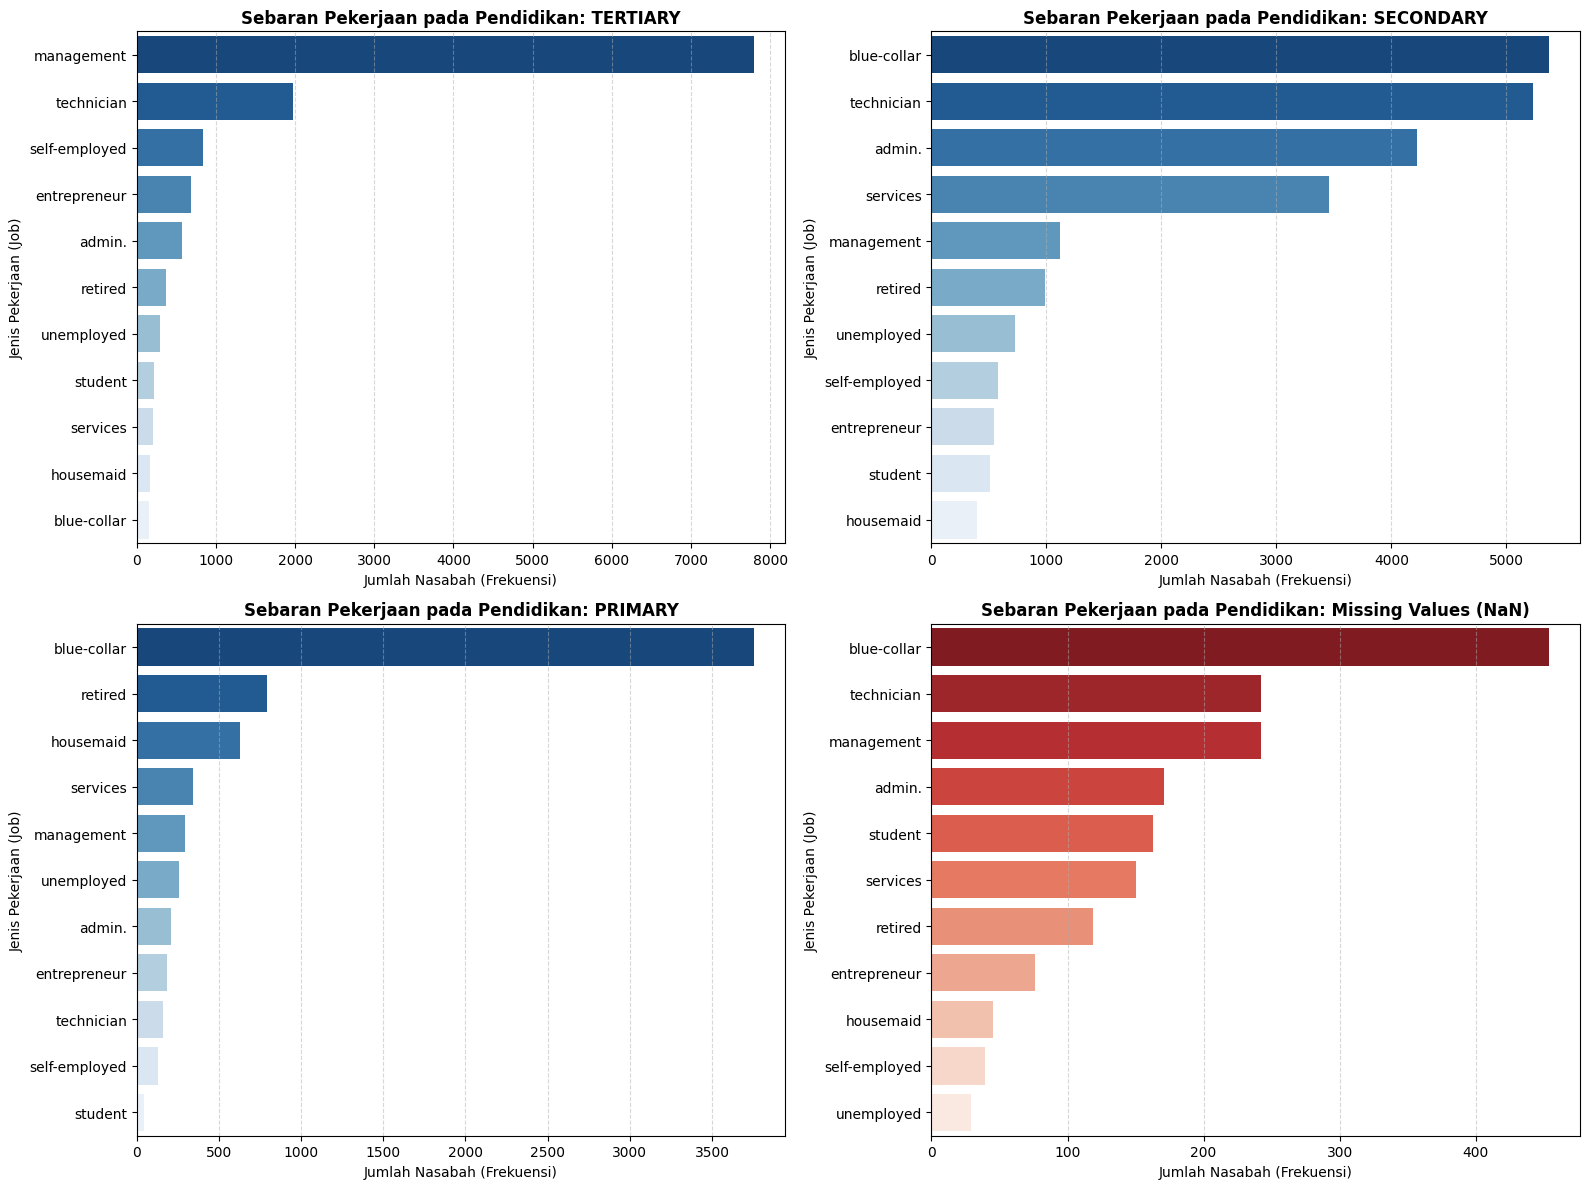

In [28]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten() 

kategori_edu = ['tertiary', 'secondary', 'primary', 'missing_nan']

for i, edu in enumerate(kategori_edu):
    if edu == 'missing_nan':
        subset_data = data[data['education'].isnull()]
        title_text = "Sebaran Pekerjaan pada Pendidikan: Missing Values (NaN)"
        color_palette = "Reds_r"
    else:
        subset_data = data[data['education'] == edu]
        title_text = f"Sebaran Pekerjaan pada Pendidikan: {edu.upper()}"
        color_palette = "Blues_r"

    job_counts = subset_data['job'].value_counts()
    
    sns.barplot(
        x=job_counts.values, 
        y=job_counts.index, 
        ax=axes[i], 
        palette=color_palette,
        hue=job_counts.index, 
        legend=False
    )
    
    axes[i].set_title(title_text, fontsize=12, fontweight='bold')
    axes[i].set_xlabel("Jumlah Nasabah (Frekuensi)", fontsize=10)
    axes[i].set_ylabel("Jenis Pekerjaan (Job)", fontsize=10)
    axes[i].grid(axis='x', linestyle='--', alpha=0.5) 

plt.tight_layout()

plt.show()

### Interpretasi

Berdasarkan visualisasi, distribusi jenis pekerjaan pada data yang memiliki nilai pendidikan kosong menunjukkan pola yang relatif mirip dengan beberapa kategori pendidikan yang telah diketahui. Hal ini mengindikasikan bahwa variabel `job` dapat digunakan sebagai dasar untuk melakukan imputasi pada variabel `education`.

Selain itu, variabel `job` hanya memiliki sedikit nilai yang hilang sehingga terlebih dahulu dilakukan imputasi menggunakan modus (kategori yang paling sering muncul). Setelah itu, nilai hilang pada `education` diisi berdasarkan kategori pendidikan yang paling dominan pada masing-masing jenis pekerjaan.

### Imputasi Missing Value

Proses imputasi dilakukan dalam dua tahap:

1. Mengisi nilai hilang pada variabel `job` menggunakan modus global.
2. Mengisi nilai hilang pada variabel `education` menggunakan modus tingkat pendidikan pada setiap kelompok pekerjaan (`job`).

Pendekatan ini dipilih untuk mempertahankan hubungan antara jenis pekerjaan dan tingkat pendidikan sehingga hasil imputasi menjadi lebih realistis dibandingkan menggunakan modus keseluruhan data.

In [29]:
data['job'] = data['job'].fillna(data['job'].mode()[0])

data['education'] = data.groupby('job')['education'].transform(
    lambda x: x.fillna(x.mode()[0] if not x.mode().empty else 'secondary')
)

### Hasil Imputasi

Nilai hilang pada variabel `job` dan `education` berhasil ditangani. Dengan memanfaatkan informasi dari variabel yang saling berkaitan, proses imputasi diharapkan dapat mempertahankan karakteristik data dan mengurangi potensi bias pada tahap analisis selanjutnya.

## 3.4 Penghapusan Variabel `contact`

Berdasarkan hasil eksplorasi data, variabel `contact` memiliki proporsi nilai hilang yang sangat besar sehingga informasi yang tersedia menjadi kurang representatif untuk digunakan dalam analisis.

Oleh karena itu, variabel `contact` dihapus dari dataset untuk mengurangi kompleksitas data dan menghindari potensi bias yang dapat memengaruhi hasil pemodelan.

In [30]:
data = data.drop(columns=['contact'])

## 4.1 Analisis Hubungan Jenis Pekerjaan dengan Keputusan Deposito

Sebelum melakukan proses clustering dan klasifikasi, dilakukan analisis untuk mengetahui hubungan antara jenis pekerjaan nasabah dan keputusan berlangganan deposito berjangka. Analisis ini bertujuan untuk mengidentifikasi apakah terdapat perbedaan kecenderungan berlangganan deposito pada masing-masing kelompok pekerjaan.

Visualisasi berikut menampilkan persentase nasabah yang berlangganan dan tidak berlangganan deposito untuk setiap kategori pekerjaan.

<Figure size 1400x600 with 0 Axes>

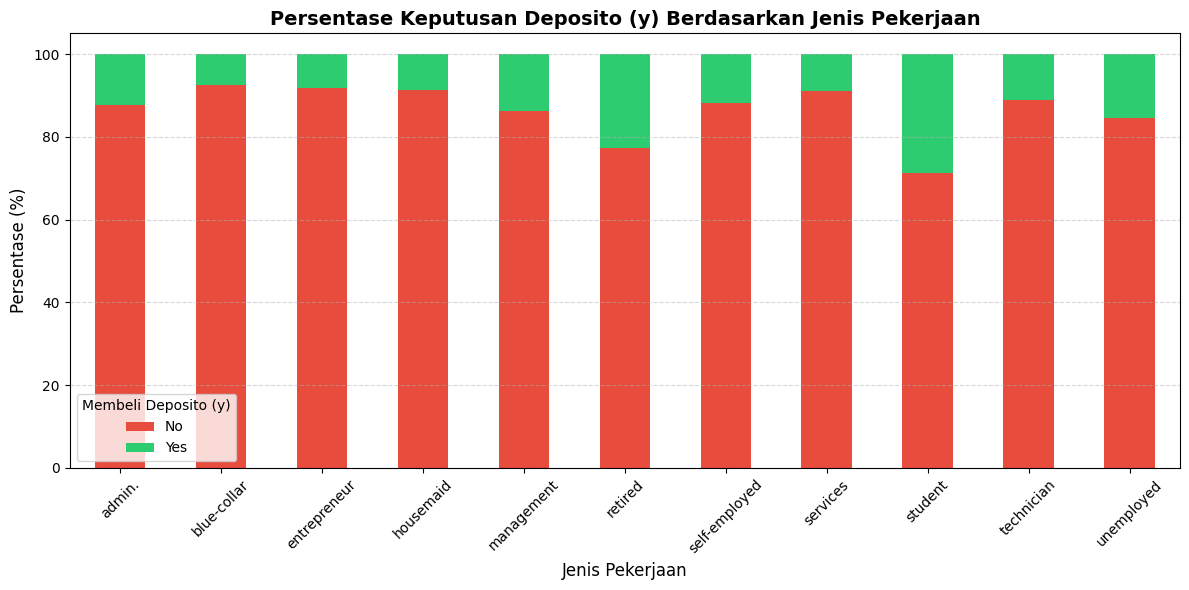

In [31]:
plt.figure(figsize=(14, 6))
job_y_cross = pd.crosstab(data['job'], data['y'], normalize='index') * 100

job_y_cross.plot(kind='bar', stacked=True, color=['#e74c3c', '#2ecc71'], figsize=(12, 6))
plt.title('Persentase Keputusan Deposito (y) Berdasarkan Jenis Pekerjaan', fontsize=14, fontweight='bold')
plt.xlabel('Jenis Pekerjaan', fontsize=12)
plt.ylabel('Persentase (%)', fontsize=12)
plt.legend(title='Membeli Deposito (y)', labels=['No', 'Yes'])
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

# 5. Feature Encoding dan Transformasi Variabel

Sebelum digunakan pada proses clustering dan klasifikasi, seluruh variabel kategorikal perlu dikonversi ke bentuk numerik agar dapat diproses oleh algoritma machine learning.

Pada tahap ini dilakukan beberapa teknik transformasi yang disesuaikan dengan karakteristik masing-masing variabel, yaitu:

- **Binary Mapping** untuk variabel biner.
- **Ordinal Encoding** untuk variabel pendidikan (`education`).
- **Transformasi Siklik (Sin-Cos)** untuk variabel waktu (`month` dan `day`).
- **Frequency Encoding** untuk variabel kategorikal nominal.

Pendekatan ini dipilih untuk mempertahankan informasi penting yang terkandung dalam setiap variabel sekaligus menghasilkan representasi numerik yang lebih sesuai untuk proses analisis.

In [ ]:
# 1. Binary Mapping (yes/no -> 1/0)
binary_cols = ['default', 'housing', 'loan', 'y']
for col in binary_cols:
    data[col] = data[col].map({'yes': 1, 'no': 0})

# 2. Ordinal Encoding untuk Education
edu_mapping = {'primary': 1, 'secondary': 2, 'tertiary': 3}
data['education'] = data['education'].map(edu_mapping)

# 3. KANONIKAL SIKLIK untuk 'month'
month_map = {'jan':1, 'feb':2, 'mar':3, 'apr':4, 'may':5, 'jun':6, 'jul':7, 'aug':8, 'sep':9, 'oct':10, 'nov':11, 'dec':12}
data['month'] = data['month'].map(month_map)

# Rumus transformasi siklik sin/cos
data['month_sin'] = np.sin(2 * np.pi * data['month'] / 12)
data['month_cos'] = np.cos(2 * np.pi * data['month'] / 12)
data['day_sin'] = np.sin(2 * np.pi * data['day'] / 31)
data['day_cos'] = np.cos(2 * np.pi * data['day'] / 31)

data = data.drop(columns=['day', 'month'])

# 4. Frequency Encoding untuk kolom nominal lainnya
nominal_cols = ['job', 'marital', 'poutcome']
for col in nominal_cols:
    freq_map = data[col].value_counts(normalize=True)
    data[col] = data[col].map(freq_map)

data = data.astype(float)

In [34]:
data.head()

,age,job,marital,education,default,balance,housing,loan,duration,campaign,pdays,previous,poutcome,y,month_sin,month_cos,day_sin,day_cos
0,58.0,0.209197,0.601933,3.0,0.0,2143.0,1.0,0.0,261.0,1.0,-1.0,0.0,0.817367,0.0,0.5,-0.866025,0.848644,0.528964
1,44.0,0.168034,0.282896,2.0,0.0,29.0,1.0,0.0,151.0,1.0,-1.0,0.0,0.817367,0.0,0.5,-0.866025,0.848644,0.528964
2,33.0,0.032890,0.601933,2.0,0.0,2.0,1.0,1.0,76.0,1.0,-1.0,0.0,0.817367,0.0,0.5,-0.866025,0.848644,0.528964
3,47.0,0.221627,0.601933,2.0,0.0,1506.0,1.0,0.0,92.0,1.0,-1.0,0.0,0.817367,0.0,0.5,-0.866025,0.848644,0.528964
4,33.0,0.221627,0.282896,2.0,0.0,1.0,0.0,0.0,198.0,1.0,-1.0,0.0,0.817367,0.0,0.5,-0.866025,0.848644,0.528964


In [35]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 18 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   age        45211 non-null  float64
 1   job        45211 non-null  float64
 2   marital    45211 non-null  float64
 3   education  45211 non-null  float64
 4   default    45211 non-null  float64
 5   balance    45211 non-null  float64
 6   housing    45211 non-null  float64
 7   loan       45211 non-null  float64
 8   duration   45211 non-null  float64
 9   campaign   45211 non-null  float64
 10  pdays      45211 non-null  float64
 11  previous   45211 non-null  float64
 12  poutcome   45211 non-null  float64
 13  y          45211 non-null  float64
 14  month_sin  45211 non-null  float64
 15  month_cos  45211 non-null  float64
 16  day_sin    45211 non-null  float64
 17  day_cos    45211 non-null  float64
dtypes: float64(18)
memory usage: 6.2 MB


## 5.2 Identifikasi Outlier Menggunakan Metode IQR

Sebelum proses pemodelan dilakukan, perlu dilakukan identifikasi terhadap nilai-nilai ekstrem (*outlier*) yang berpotensi memengaruhi distribusi data dan performa model.

Pada penelitian ini, deteksi outlier dilakukan menggunakan metode **Interquartile Range (IQR)**. Suatu observasi dikategorikan sebagai outlier apabila nilainya berada di luar rentang:

\[
Q1 - 1.5 \times IQR
\]

atau

\[
Q3 + 1.5 \times IQR
\]

dengan:

- **Q1** : Kuartil pertama (25%)
- **Q3** : Kuartil ketiga (75%)
- **IQR** : Interquartile Range (\(Q3 - Q1\))

Visualisasi boxplot digunakan untuk mengamati keberadaan outlier pada setiap variabel numerik yang digunakan dalam analisis.

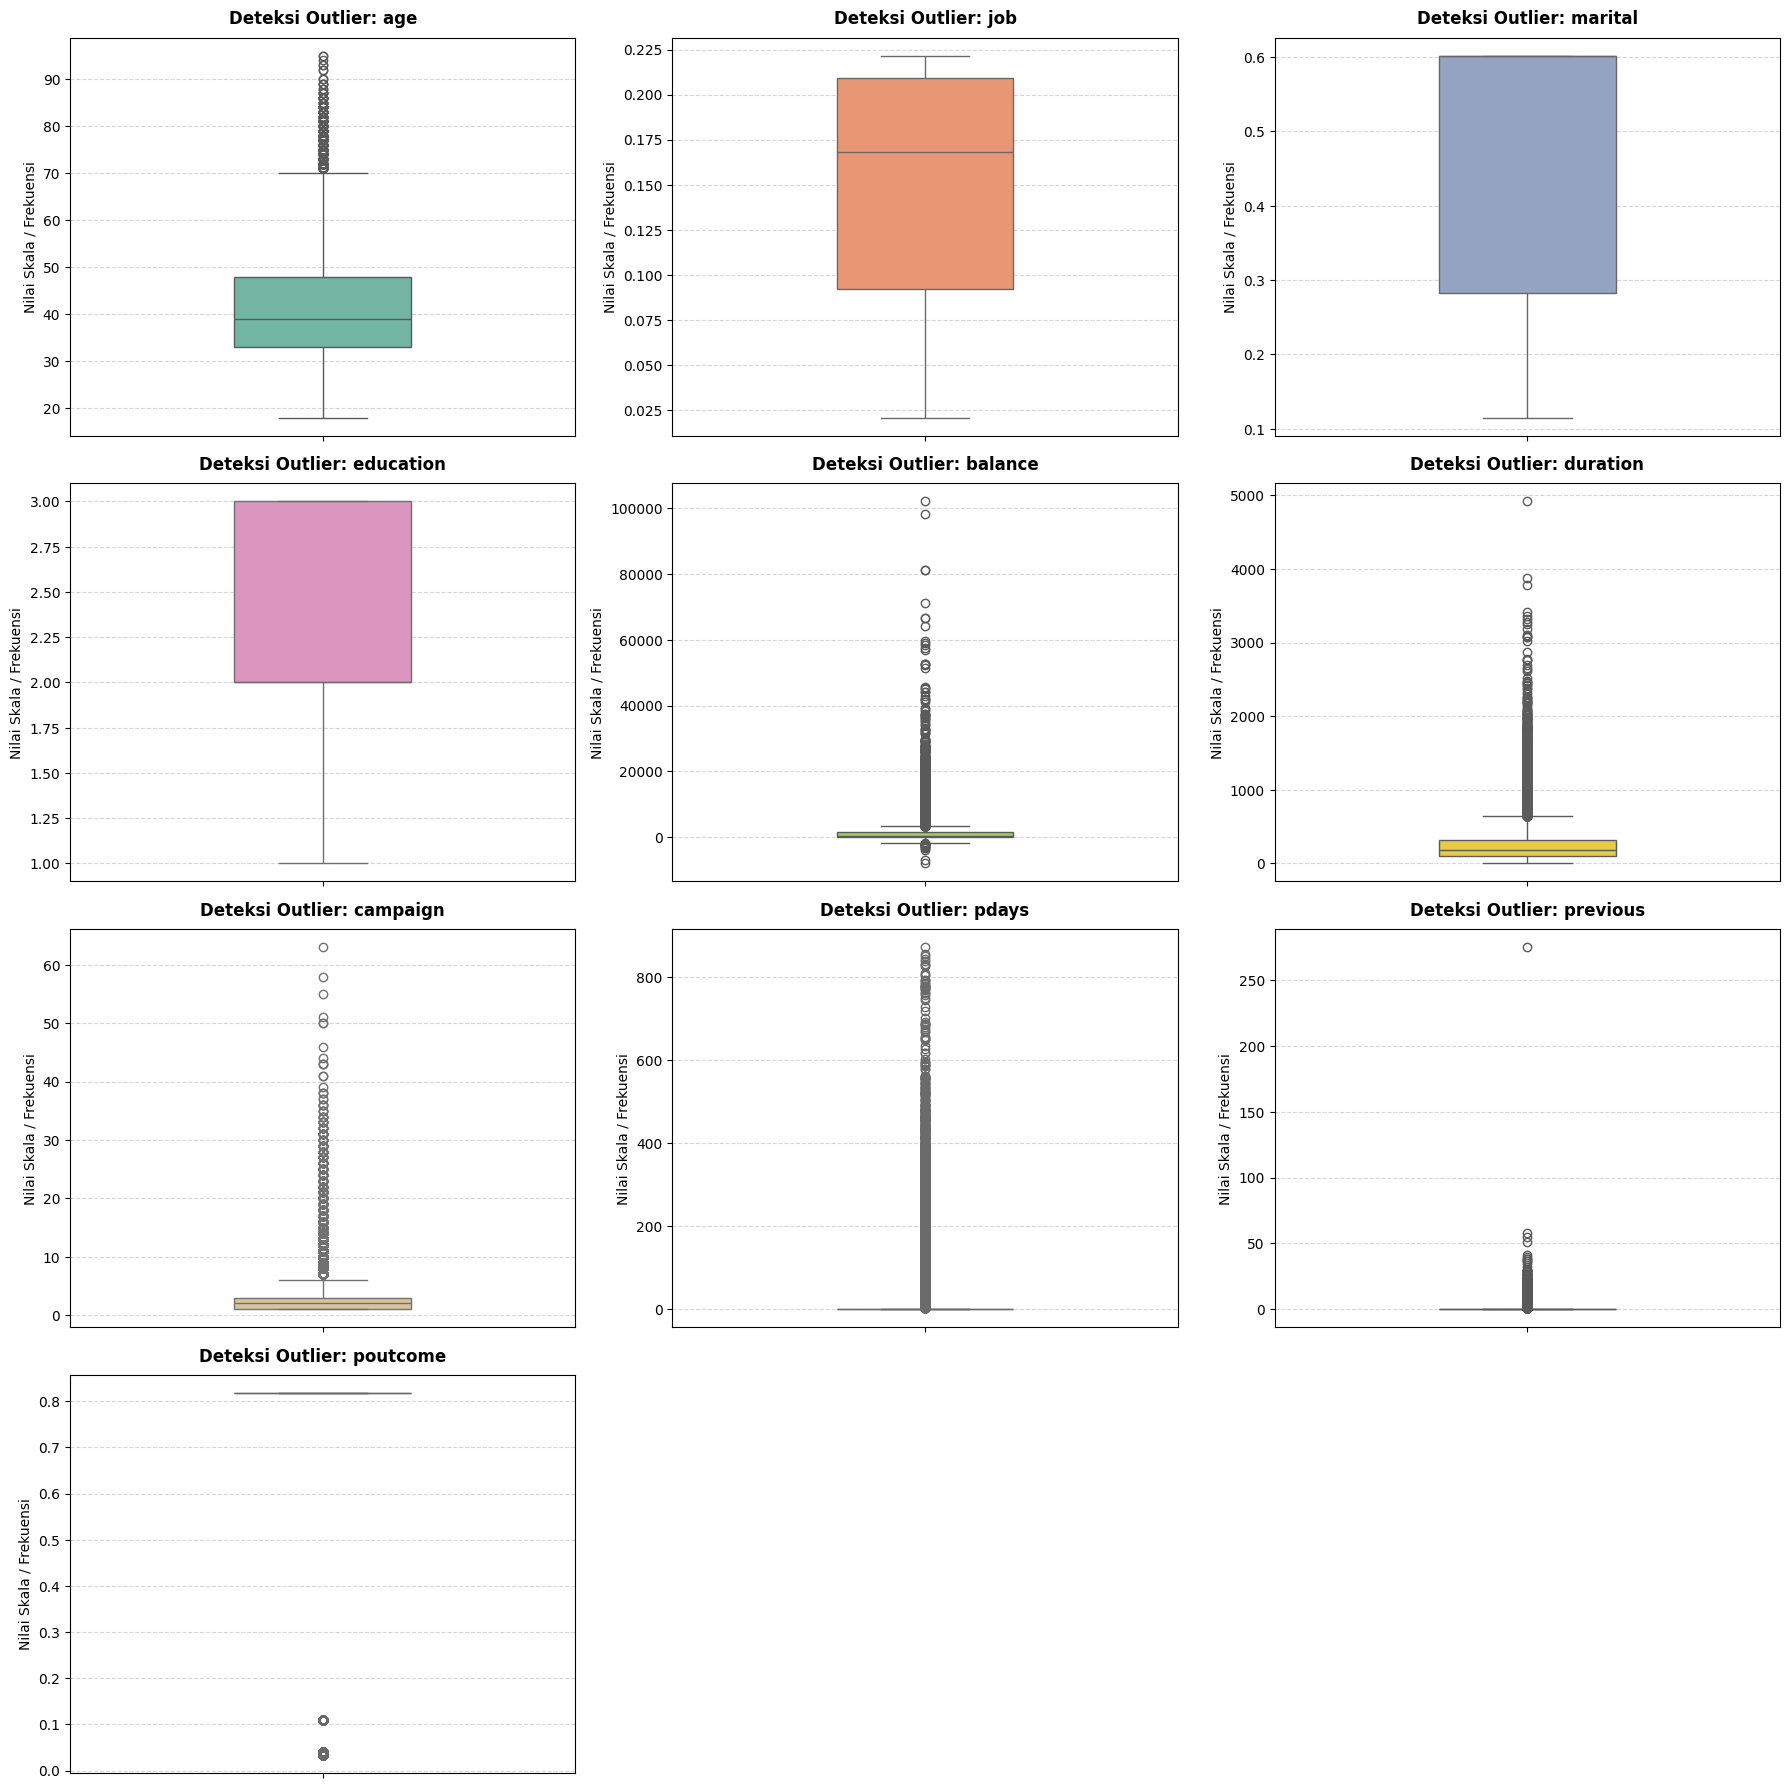


 RANGKUMAN ANALISIS STATISTIK OUTLIER (METODE IQR) 
KOLOM: AGE
  - Batas Bawah : 10.5000
  - Median      : 39.0000
  - Batas Atas  : 70.5000
  - Total Data  : 45211 baris
  - Jml Outlier : 487 baris (1.08%)
--------------------------------------------------
KOLOM: JOB
  - Batas Bawah : -0.0841
  - Median      : 0.1680
  - Batas Atas  : 0.3852
  - Total Data  : 45211 baris
  - Jml Outlier : 0 baris (0.00%)
--------------------------------------------------
KOLOM: MARITAL
  - Batas Bawah : -0.1957
  - Median      : 0.6019
  - Batas Atas  : 1.0805
  - Total Data  : 45211 baris
  - Jml Outlier : 0 baris (0.00%)
--------------------------------------------------
KOLOM: EDUCATION
  - Batas Bawah : 0.5000
  - Median      : 2.0000
  - Batas Atas  : 4.5000
  - Total Data  : 45211 baris
  - Jml Outlier : 0 baris (0.00%)
--------------------------------------------------
KOLOM: BALANCE
  - Batas Bawah : -1962.0000
  - Median      : 448.0000
  - Batas Atas  : 3462.0000
  - Total Data  : 45211 bar

In [ ]:

df_aktif = data 

kolom_diabaikan = ['default', 'housing', 'loan', 'y', 'month_sin', 'month_cos', 'day_sin', 'day_cos']
semua_kolom = [col for col in df_aktif.columns if col not in kolom_diabaikan]
jumlah_fitur = len(semua_kolom)

n_cols = 3
n_rows = math.ceil(jumlah_fitur / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, n_rows * 4.5))
axes = axes.flatten()

laporan_statistik = []

for i, col in enumerate(semua_kolom):
    q1 = df_aktif[col].quantile(0.25)
    median = df_aktif[col].median()
    q3 = df_aktif[col].quantile(0.75)
    iqr = q3 - q1
    
    batas_bawah = q1 - (1.5 * iqr)
    batas_atas = q3 + (1.5 * iqr)
    
    jumlah_outlier = df_aktif[(df_aktif[col] < batas_bawah) | (df_aktif[col] > batas_atas)].shape[0]
    persentase_outlier = (jumlah_outlier / df_aktif.shape[0]) * 100
    
    info_kolom = (
        f"KOLOM: {col.upper()}\n"
        f"  - Batas Bawah : {batas_bawah:.4f}\n"
        f"  - Median      : {median:.4f}\n"
        f"  - Batas Atas  : {batas_atas:.4f}\n"
        f"  - Total Data  : {df_aktif.shape[0]} baris\n"
        f"  - Jml Outlier : {jumlah_outlier} baris ({persentase_outlier:.2f}%)\n"
        f"{'-'*50}"
    )
    laporan_statistik.append(info_kolom)
    
    sns.boxplot(y=df_aktif[col], ax=axes[i], color=sns.color_palette("Set2")[i % 8], width=0.35)
    
    axes[i].set_title(f'Deteksi Outlier: {col}', fontsize=12, fontweight='bold', pad=10)
    axes[i].set_ylabel('Nilai Skala / Frekuensi', fontsize=10)
    axes[i].grid(axis='y', linestyle='--', alpha=0.5)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

print("\n" + "="*55)
print(" RANGKUMAN ANALISIS STATISTIK OUTLIER (METODE IQR) ")
print("="*55)
for laporan in laporan_statistik:
    print(laporan)

## 5.3 Analisis Distribusi Variabel Numerik

Selain menggunakan boxplot untuk mendeteksi outlier, distribusi setiap variabel numerik juga perlu dianalisis menggunakan histogram dan kurva kepadatan (*Kernel Density Estimation* / KDE).

Analisis ini bertujuan untuk memahami bentuk distribusi data, tingkat kemencengan (*skewness*), serta keberadaan nilai ekstrem yang dapat memengaruhi proses clustering dan klasifikasi.

Variabel yang diamati meliputi:

- `age`
- `balance`
- `duration`
- `campaign`
- `pdays`
- `previous`

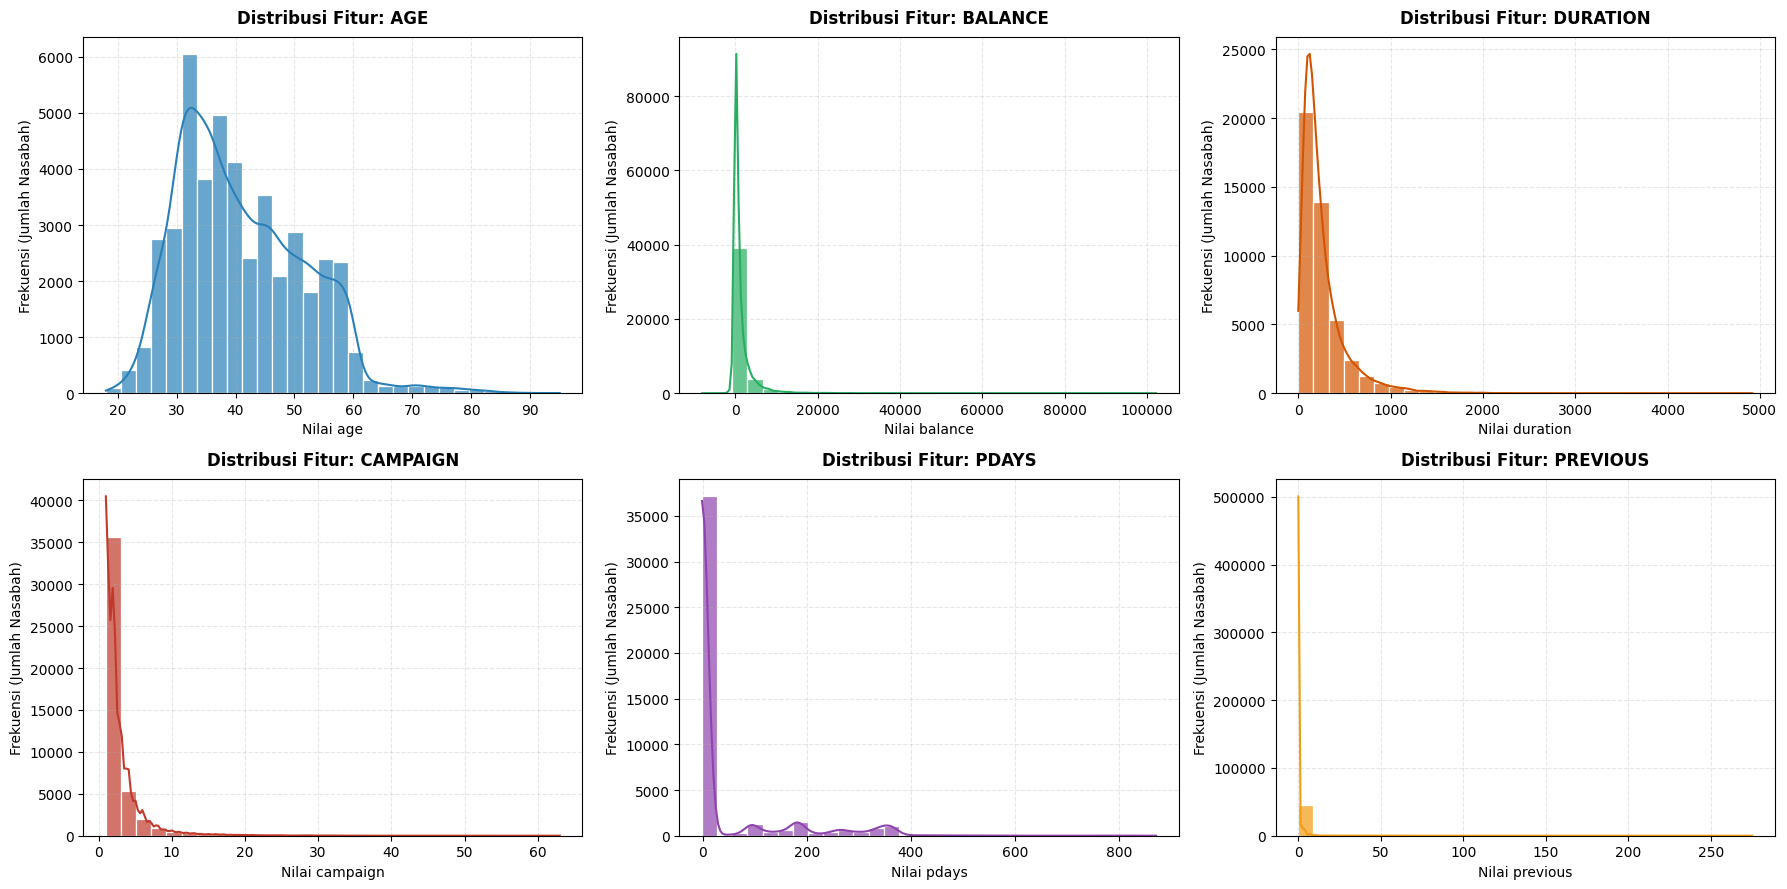

In [ ]:

kolom_numerik = ['age', 'balance', 'duration', 'campaign', 'pdays', 'previous']

kolom_yang_ada = [col for col in kolom_numerik if col in data.columns]
jumlah_fitur = len(kolom_yang_ada)

n_cols = 3
n_rows = math.ceil(jumlah_fitur / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, n_rows * 4.5))
axes = axes.flatten()

colors = ['#2980b9', '#27ae60', '#d35400', '#c0392b', '#8e44ad', '#f39c12', '#16a085']

for i, col in enumerate(kolom_yang_ada):
    sns.histplot(
        data=data, 
        x=col, 
        ax=axes[i], 
        kde=True,                 
        color=colors[i % len(colors)],
        bins=30,                  
        edgecolor='white',        
        alpha=0.7
    )
    
    axes[i].set_title(f'Distribusi Fitur: {col.upper()}', fontsize=12, fontweight='bold', pad=10)
    axes[i].set_xlabel(f'Nilai {col}', fontsize=10)
    axes[i].set_ylabel('Frekuensi (Jumlah Nasabah)', fontsize=10)
    axes[i].grid(True, linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

## 5.4 Penanganan Outlier Menggunakan Winsorisasi

Berdasarkan hasil deteksi outlier menggunakan metode IQR, ditemukan beberapa variabel yang memiliki nilai ekstrem dalam jumlah cukup besar, terutama pada variabel `balance`, `campaign`, dan `previous`.

Pada penelitian ini, penanganan outlier dilakukan menggunakan metode **winsorisasi**, yaitu dengan membatasi nilai ekstrem pada **persentil ke-99** tanpa menghapus observasi dari dataset. Pendekatan ini dipilih agar informasi penting tetap dipertahankan sekaligus mengurangi pengaruh nilai yang terlalu ekstrem terhadap proses analisis.

Visualisasi berikut membandingkan distribusi data sebelum dan sesudah proses winsorisasi menggunakan boxplot dan histogram.

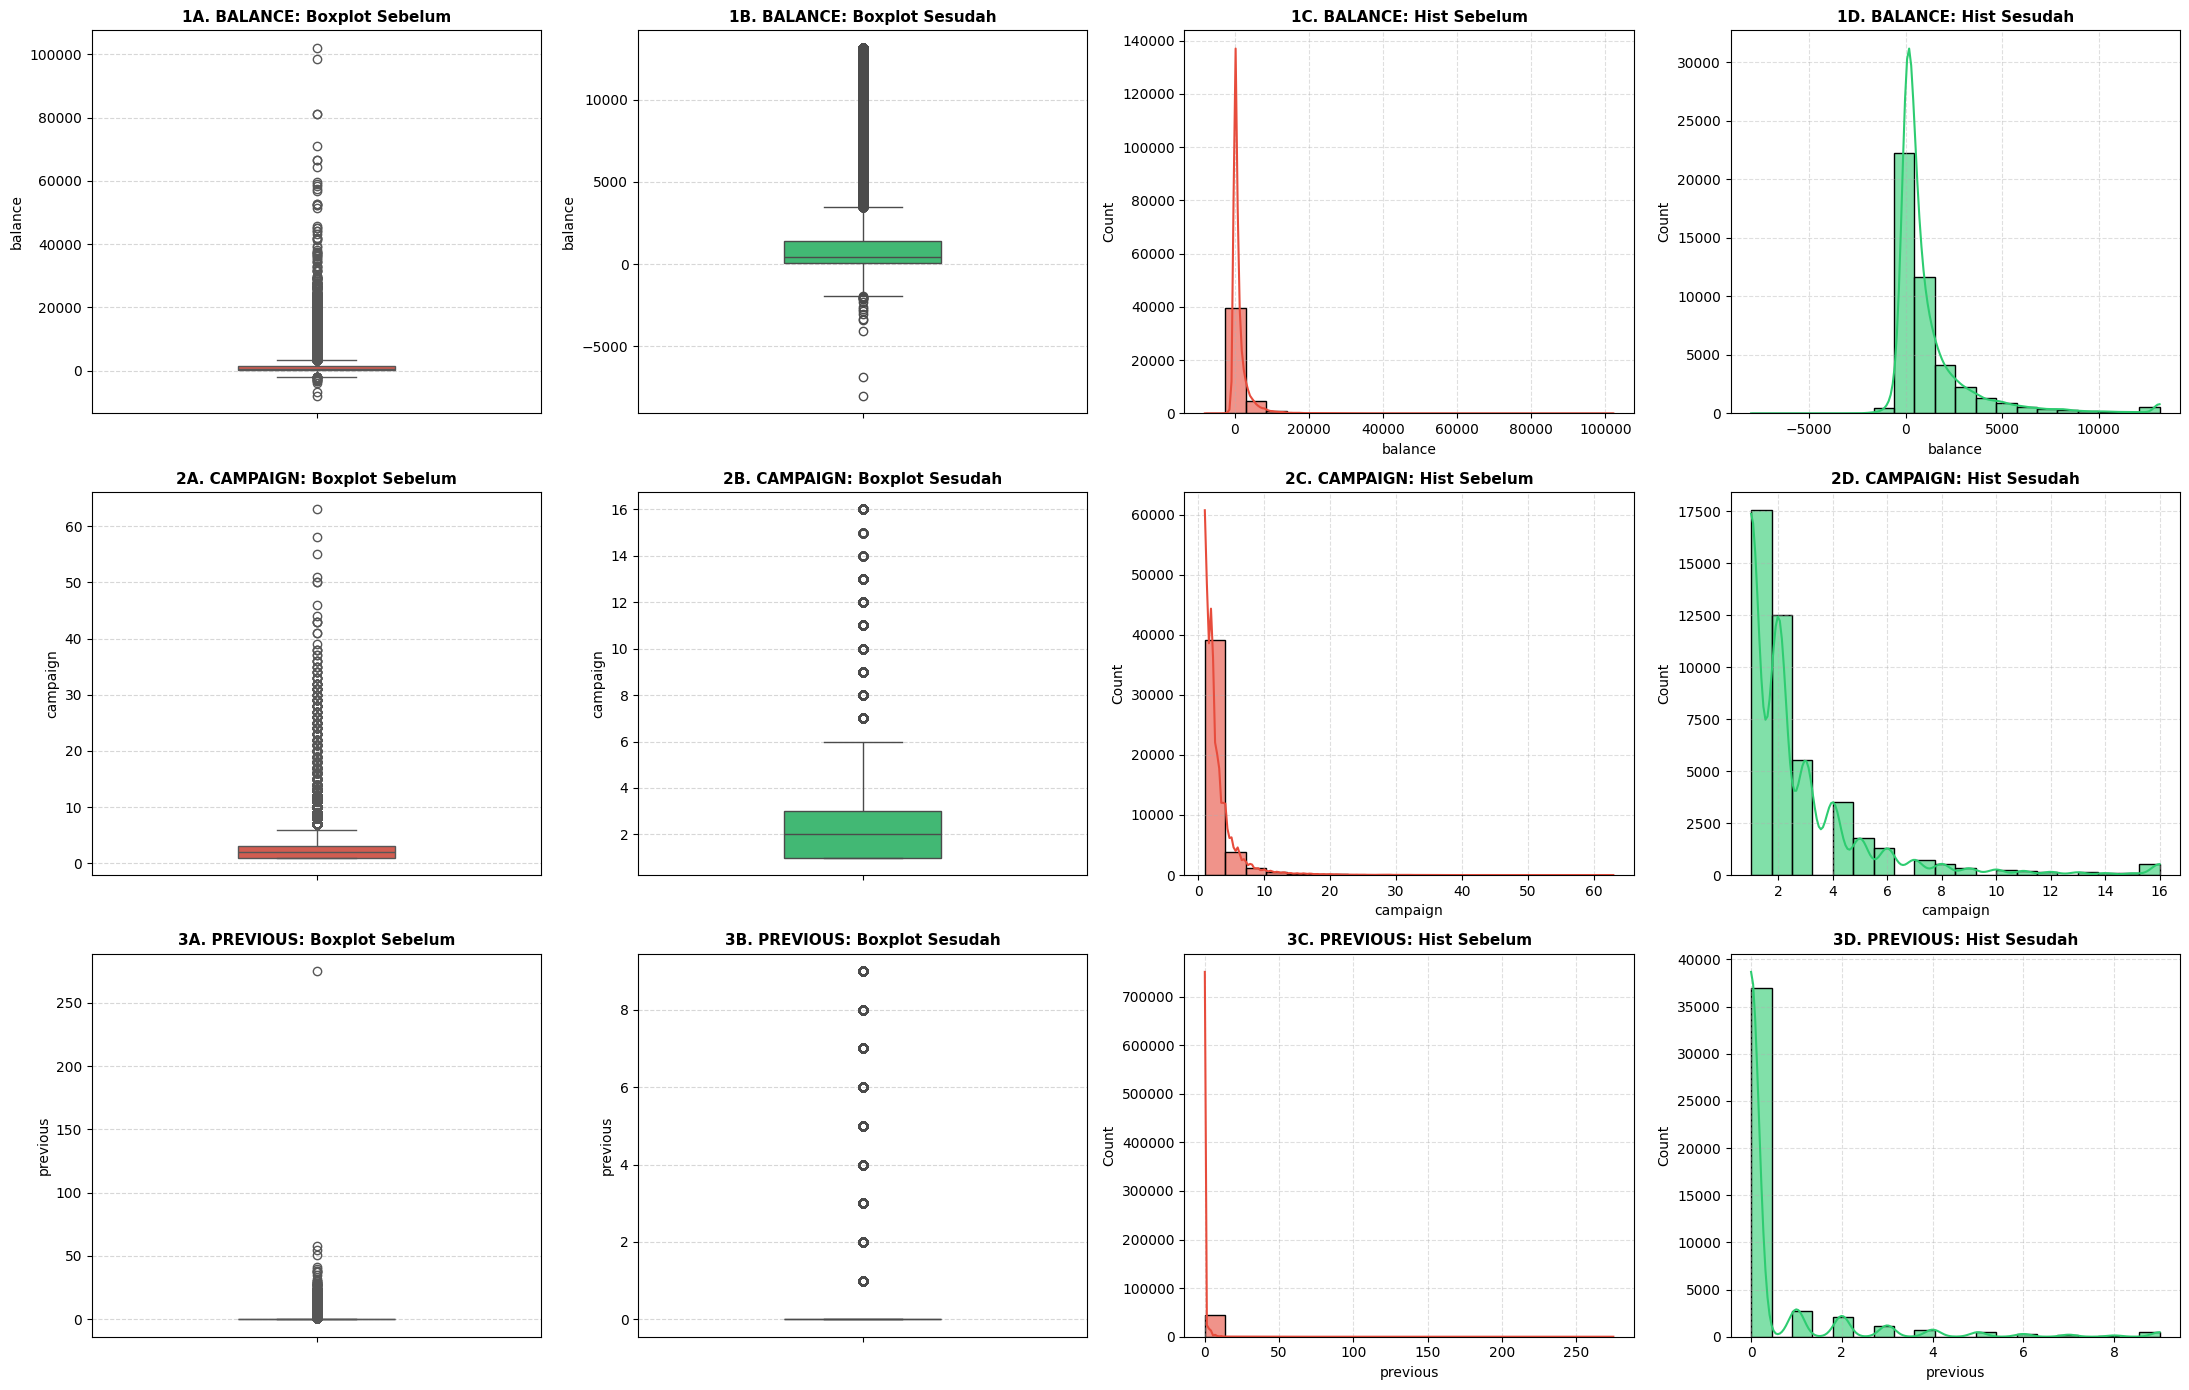

Max value PREVIOUS setelah dijinakkan: 9.0


In [ ]:

df_winsorized = data.copy()
df_winsorized['balance'] = winsorize(df_winsorized['balance'], limits=[0, 0.01])
df_winsorized['campaign'] = winsorize(df_winsorized['campaign'], limits=[0, 0.01])
df_winsorized['previous'] = winsorize(df_winsorized['previous'], limits=[0, 0.01])

fig, axes = plt.subplots(3, 4, figsize=(22, 14))

fitur_evaluasi = ['balance', 'campaign', 'previous']
colors_sebelum = '#e74c3c'
colors_sesudah = '#2ecc71'

for row, col in enumerate(fitur_evaluasi):
    # Boxplot Sebelum vs Sesudah
    sns.boxplot(y=data[col], ax=axes[row, 0], color=colors_sebelum, width=0.35)
    axes[row, 0].set_title(f'{row+1}A. {col.upper()}: Boxplot Sebelum', fontsize=11, fontweight='bold')
    axes[row, 0].grid(axis='y', linestyle='--', alpha=0.5)
    
    sns.boxplot(y=df_winsorized[col], ax=axes[row, 1], color=colors_sesudah, width=0.35)
    axes[row, 1].set_title(f'{row+1}B. {col.upper()}: Boxplot Sesudah', fontsize=11, fontweight='bold')
    axes[row, 1].grid(axis='y', linestyle='--', alpha=0.5)
    
    # Histogram Sebelum vs Sesudah
    sns.histplot(data[col], ax=axes[row, 2], color=colors_sebelum, kde=True, bins=20, alpha=0.6)
    axes[row, 2].set_title(f'{row+1}C. {col.upper()}: Hist Sebelum', fontsize=11, fontweight='bold')
    axes[row, 2].grid(linestyle='--', alpha=0.4)
    
    sns.histplot(df_winsorized[col], ax=axes[row, 3], color=colors_sesudah, kde=True, bins=20, alpha=0.6)
    axes[row, 3].set_title(f'{row+1}D. {col.upper()}: Hist Sesudah', fontsize=11, fontweight='bold')
    axes[row, 3].grid(linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()

print(f"Max value PREVIOUS setelah dijinakkan: {df_winsorized['previous'].max()}")

data = df_winsorized

## 5.5 Analisis Korelasi Antar Variabel

Setelah proses preprocessing dan penanganan outlier selesai dilakukan, langkah berikutnya adalah menganalisis hubungan antarvariabel menggunakan matriks korelasi Pearson.

Analisis korelasi bertujuan untuk:

- Mengidentifikasi hubungan antarvariabel numerik.
- Mendeteksi potensi multikolinearitas.
- Mengetahui variabel yang memiliki hubungan kuat dengan variabel target (`y`).
- Menjadi dasar dalam proses seleksi fitur dan reduksi dimensi.

Visualisasi korelasi ditampilkan dalam bentuk heatmap untuk mempermudah interpretasi hubungan antarvariabel.

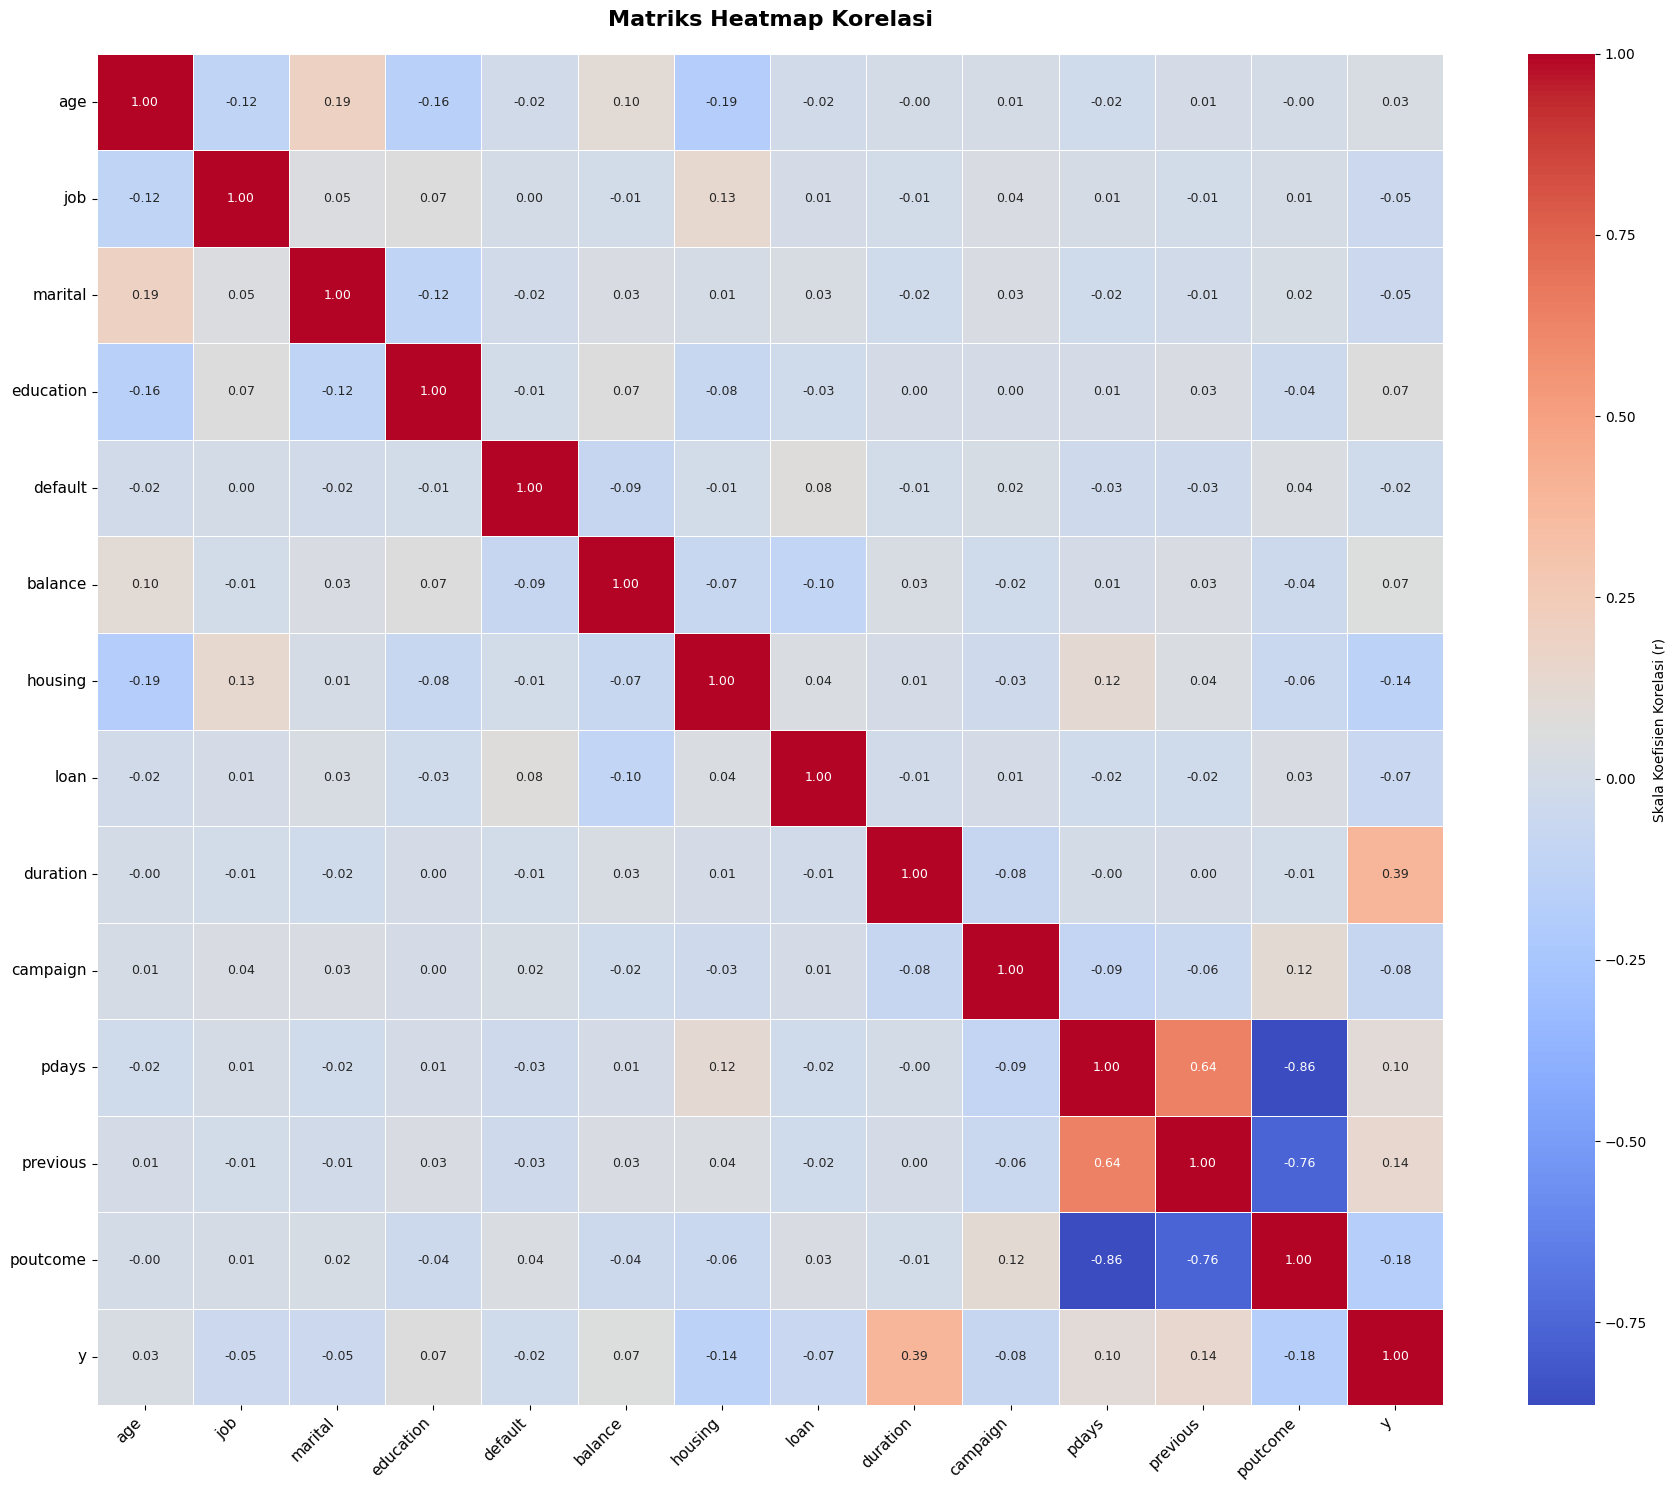

In [39]:
dataa = data.drop(columns=['month_sin', 'month_cos', 'day_sin', 'day_cos'])
matriks_korelasi = dataa.corr() 

fig, ax = plt.subplots(figsize=(18, 15))

sns.heatmap(
    matriks_korelasi, 
    annot=True,          
    cmap='coolwarm',     
    fmt='.2f',           
    linewidths=0.5,     
    annot_kws={"size": 9}, 
    ax=ax,
    cbar_kws={'label': 'Skala Koefisien Korelasi (r)'}
)

ax.set_title('Matriks Heatmap Korelasi', fontsize=16, fontweight='bold', pad=20)
plt.xticks(rotation=45, ha='right', fontsize=11)
plt.yticks(rotation=0, fontsize=11)

plt.tight_layout()

plt.savefig('heatmap_korelasi_final.png', dpi=300)

## 5.6 Principal Component Analysis (PCA)

Hasil analisis korelasi sebelumnya menunjukkan adanya korelasi negatif yang sangat kuat antara variabel `pdays` dan `poutcome`. Kondisi ini mengindikasikan adanya multikolinearitas yang dapat menyebabkan informasi menjadi redundan dan berpotensi memengaruhi proses analisis.

Untuk mengatasi permasalahan tersebut, dilakukan **Principal Component Analysis (PCA)** pada kedua variabel tersebut. PCA digunakan untuk mereduksi dimensi data dengan menggabungkan informasi dari beberapa variabel menjadi satu komponen utama yang mampu mempertahankan sebagian besar variasi data.

Pada penelitian ini, PCA diterapkan untuk menghasilkan satu fitur baru bernama `PCA_pdays_poutcome` yang selanjutnya digunakan sebagai pengganti variabel `pdays` dan `poutcome`.

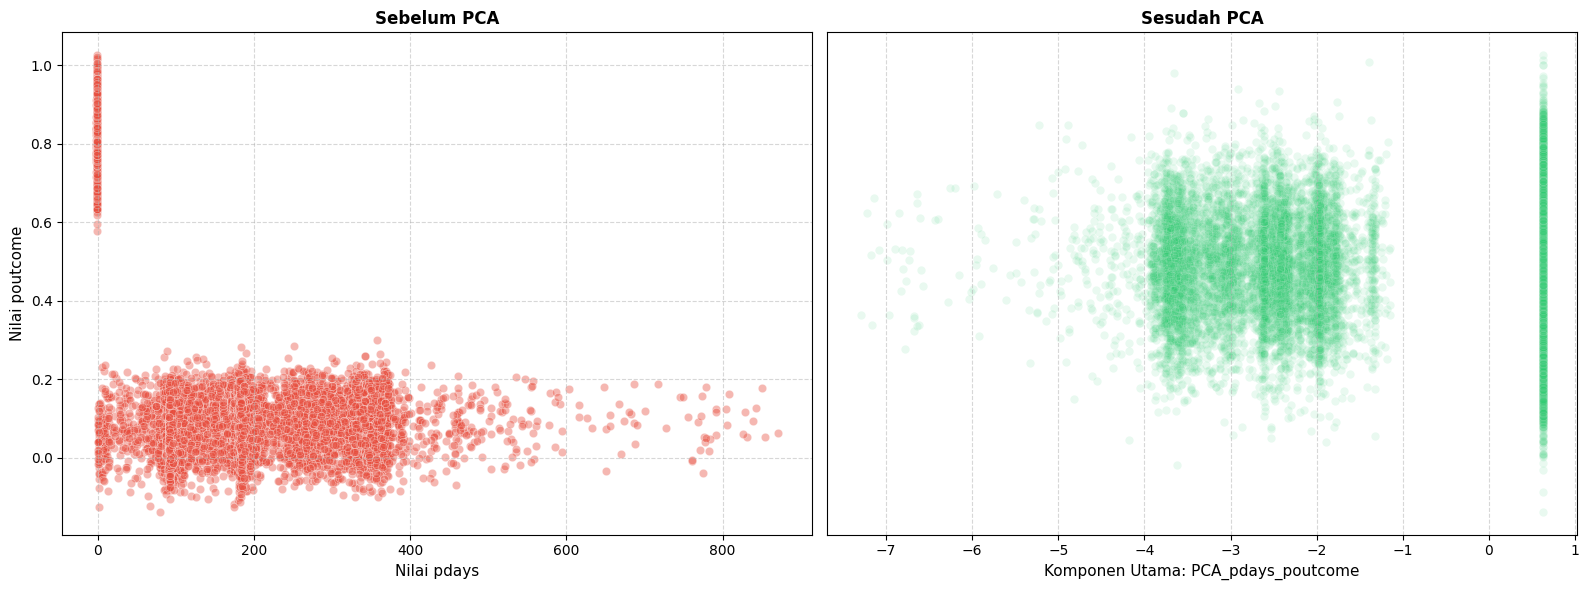


 NARASI ANALISIS FORENSIK PCA (SIAP COPAS KE BAB 4) 
Berdasarkan hasil pengujian, komponen utama 'PCA_pdays_poutcome' berhasil menyerap
informasi (varians) sebesar 93.22% dari kombinasi fitur pdays dan poutcome.

Analisis Visual:
1. Grafik 'Sebelum PCA' menunjukkan adanya gejala multikolinearitas yang kaku (r = -0.86)
   akibat sifat data sentinel pada pdays dan hasil frequency encoding pada poutcome.
2. Grafik 'Sesudah PCA' membuktikan bahwa reduksi dimensi berhasil memproyeksikan
   seluruh sebaran data ke dalam satu garis lurus linear (1 Dimensi murni).
   - Garis vertikal padat di sebelah kanan mewakili kelompok nasabah baru.
   - Awan data yang menyebar di sebelah kiri mewakili variasi data dari nasabah lama.

Kesimpulan Metodologi:
Langkah reduksi ini berhasil menyembuhkan penyakit multikolinearitas pada dataset
tanpa menghilangkan karakteristik esensial dari data historis kampanye perbankan.


In [ ]:

fitur_multiko = ['pdays', 'poutcome']

scaler_pca = StandardScaler()
X_scaled_pca = scaler_pca.fit_transform(data[fitur_multiko])

pca = PCA(n_components=1, random_state=42)
PC1 = pca.fit_transform(X_scaled_pca)
varians_terpelihara = pca.explained_variance_ratio_[0] * 100

data['PCA_pdays_poutcome'] = PC1

# VISUALISASI SEBELUM VS SESUDAH PCA
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
jitter_x = np.random.normal(0, 0.15, size=len(data))
jitter_y = np.random.normal(0, 0.05, size=len(data))

sns.scatterplot(
    x=data['pdays'] + jitter_x, 
    y=data['poutcome'] + jitter_y, 
    ax=axes[0], color='#e74c3c', alpha=0.4
)
axes[0].set_title('Sebelum PCA', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Nilai pdays', fontsize=11)
axes[0].set_ylabel('Nilai poutcome', fontsize=11)
axes[0].grid(True, linestyle='--', alpha=0.5)

sns.scatterplot(
    x=data['PCA_pdays_poutcome'], 
    y=np.zeros(len(data)) + jitter_y, 
    ax=axes[1], color='#2ecc71', alpha=0.1
)
axes[1].set_title(f'Sesudah PCA', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Komponen Utama: PCA_pdays_poutcome', fontsize=11)
axes[1].get_yaxis().set_visible(False)
axes[1].grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

print("\n" + "="*80)
print("="*80)
print(f"Berdasarkan hasil pengujian, komponen utama 'PCA_pdays_poutcome' berhasil menyerap")
print(f"informasi (varians) sebesar {varians_terpelihara:.2f}% dari kombinasi fitur pdays dan poutcome.")
print("\nAnalisis Visual:")
print("1. Grafik 'Sebelum PCA' menunjukkan adanya gejala multikolinearitas yang kaku (r = -0.86)")
print("   akibat sifat data sentinel pada pdays dan hasil frequency encoding pada poutcome.")
print("2. Grafik 'Sesudah PCA' membuktikan bahwa reduksi dimensi berhasil memproyeksikan")
print("   seluruh sebaran data ke dalam satu garis lurus linear (1 Dimensi murni).")
print("   - Garis vertikal padat di sebelah kanan mewakili kelompok nasabah baru.")
print("   - Awan data yang menyebar di sebelah kiri mewakili variasi data dari nasabah lama.")
print("\nKesimpulan Metodologi:")
print("Langkah reduksi ini berhasil menyembuhkan penyakit multikolinearitas pada dataset")
print("tanpa menghilangkan karakteristik esensial dari data historis kampanye perbankan.")
print("="*80)

## 5.7 Pembersihan Fitur untuk Pemodelan

Setelah proses PCA selesai dilakukan, tahap berikutnya adalah membersihkan fitur yang tidak lagi digunakan dalam analisis.

Beberapa variabel dihapus dengan pertimbangan sebagai berikut:

- `duration` dihapus karena berpotensi menyebabkan **data leakage**, mengingat informasi durasi panggilan hanya diketahui setelah proses telemarketing selesai dilakukan.
- `pdays` dan `poutcome` dihapus karena informasi dari kedua variabel tersebut telah direpresentasikan ke dalam fitur baru `PCA_pdays_poutcome`.

Langkah ini dilakukan untuk menghindari redundansi informasi dan memastikan bahwa dataset yang digunakan pada tahap clustering dan klasifikasi hanya berisi fitur yang relevan.

In [41]:
kolom_drop = ['duration', 'pdays', 'poutcome']

data = data.drop(columns=[col for col in kolom_drop if col in data.columns])
print(f"Kolom yang berhasil di-drop (Pembersihan Multiko & Leakage)  : {kolom_drop}")

Kolom yang berhasil di-drop (Pembersihan Multiko & Leakage)  : ['duration', 'pdays', 'poutcome']


In [42]:
data.describe()

,age,job,marital,education,default,balance,housing,loan,campaign,previous,y,month_sin,month_cos,day_sin,day_cos,PCA_pdays_poutcome
count,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,4.521100e+04,45211.000000,45211.000000,45211.000000,4.521100e+04
mean,40.936210,0.149464,0.455618,2.149565,0.018027,1274.154454,0.555838,0.160226,2.691403,0.525691,0.116985,1.844906e-02,-0.470301,0.027214,-0.106996,-1.408167e-16
std,10.618762,0.070538,0.186213,0.657468,0.133049,2253.929019,0.496878,0.366820,2.585740,1.463596,0.321406,6.127310e-01,0.634865,0.698901,0.706661,1.365439e+00
min,18.000000,0.020747,0.115171,1.000000,0.000000,-8019.000000,0.000000,0.000000,1.000000,0.000000,0.000000,-1.000000e+00,-1.000000,-0.998717,-0.994869,-7.289626e+00
25%,33.000000,0.091880,0.282896,2.000000,0.000000,72.000000,0.000000,0.000000,1.000000,0.000000,0.000000,-5.000000e-01,-0.866025,-0.651372,-0.758758,6.247298e-01
50%,39.000000,0.168034,0.601933,2.000000,0.000000,448.000000,1.000000,0.000000,2.000000,0.000000,0.000000,1.224647e-16,-0.866025,-0.101168,-0.250653,6.247298e-01
75%,48.000000,0.209197,0.601933,3.000000,0.000000,1428.000000,1.000000,0.000000,3.000000,0.000000,0.000000,5.000000e-01,-0.500000,0.724793,0.528964,6.247298e-01
max,95.000000,0.221627,0.601933,3.000000,1.000000,13165.000000,1.000000,1.000000,16.000000,9.000000,1.000000,1.000000e+00,1.000000,0.998717,1.000000,6.247298e-01


## 5.8 Transformasi Logaritma

Beberapa variabel numerik masih menunjukkan distribusi yang miring ke kanan (*right-skewed*) meskipun telah dilakukan penanganan outlier. Distribusi yang sangat tidak seimbang dapat memengaruhi proses clustering dan pembelajaran model machine learning.

Untuk mengurangi tingkat kemencengan distribusi, dilakukan transformasi logaritma menggunakan fungsi `log1p()`. Metode ini dipilih karena mampu mengompresi rentang nilai yang sangat besar tanpa menghilangkan informasi penting pada data.

Transformasi diterapkan pada variabel:

- `balance`
- `campaign`
- `previous`

Khusus untuk variabel `balance`, dilakukan proses *shifting* terlebih dahulu karena terdapat nilai negatif pada data.## Tranform

In [ ]:

# 1. Kolom BALANCE (Gunakan teknik Shift karena nilai minimumnya negatif -8019)
min_balance = data['balance'].min()
data['balance'] = np.log1p(data['balance'] + abs(min_balance))

# 2. Kolom CAMPAIGN (Langsung Log1p karena nilai minimumnya >= 0)
data['campaign'] = np.log1p(data['campaign'])

# 3. Kolom PREVIOUS (Langsung Log1p karena nilai minimumnya >= 0)
data['previous'] = np.log1p(data['previous'])

## 5.9 Standardisasi Fitur

Variabel dalam dataset memiliki satuan dan rentang nilai yang berbeda-beda. Sebagai contoh, variabel `age` memiliki skala yang berbeda dengan `balance`, `campaign`, maupun `PCA_pdays_poutcome`.

Perbedaan skala tersebut dapat menyebabkan variabel tertentu mendominasi proses perhitungan jarak pada algoritma clustering dan memengaruhi proses pembelajaran model machine learning.

Untuk mengatasi permasalahan tersebut, dilakukan standardisasi menggunakan **StandardScaler**, yang mentransformasikan data sehingga memiliki:

- Rata-rata (*mean*) ≈ 0
- Standar deviasi (*standard deviation*) ≈ 1

Standardisasi diterapkan pada seluruh fitur numerik yang digunakan dalam proses segmentasi nasabah dan klasifikasi.

In [ ]:

fitur_aktif = [
    'age', 'balance', 'campaign', 'previous', 'education',
    'housing', 'loan', 'job', 'marital', 'PCA_pdays_poutcome'
]

X_data = data[fitur_aktif]

# scaling
scaler = StandardScaler()
X_scaled_array = scaler.fit_transform(X_data)

# jadikan DataFrame + SAMAKAN INDEX
df_scaled = pd.DataFrame(X_scaled_array, columns=X_data.columns, index=data.index)

# gabungkan lagi dengan kolom lain
data = pd.concat(
    [df_scaled, data[['default', 'month_sin', 'month_cos', 'day_sin', 'day_cos', 'y']]],
    axis=1
)

data

,age,balance,campaign,previous,education,housing,loan,job,marital,PCA_pdays_poutcome,default,month_sin,month_cos,day_sin,day_cos,y
0,1.606965,0.564229,-0.925422,-0.430981,1.293515,0.893915,-0.436803,0.846834,0.785748,0.457535,0.0,0.5,-0.866025,0.848644,0.528964,0.0
1,0.288529,-0.622807,-0.925422,-0.430981,-0.227490,0.893915,-0.436803,0.263275,-0.927560,0.457535,0.0,0.5,-0.866025,0.848644,0.528964,0.0
2,-0.747384,-0.639910,-0.925422,-0.430981,-0.227490,0.893915,2.289359,-1.652655,0.785748,0.457535,0.0,0.5,-0.866025,0.848644,0.528964,0.0
3,0.571051,0.234755,-0.925422,-0.430981,-0.227490,0.893915,-0.436803,1.023062,0.785748,0.457535,0.0,0.5,-0.866025,0.848644,0.528964,0.0
4,-0.747384,-0.640544,-0.925422,-0.430981,-0.227490,-1.118674,-0.436803,1.023062,-0.927560,0.457535,0.0,0.5,-0.866025,0.848644,0.528964,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
45206,0.947747,-0.142789,0.462446,-0.430981,1.293515,-1.118674,-0.436803,0.263275,0.785748,0.457535,0.0,-0.5,0.866025,-0.299363,-0.954139,1.0
45207,2.831227,0.352538,-0.113571,-0.430981,-1.748494,-1.118674,-0.436803,-1.409009,-1.828281,0.457535,0.0,-0.5,0.866025,-0.299363,-0.954139,1.0
45208,2.925401,2.097329,1.274297,2.248360,-0.227490,-1.118674,-0.436803,-1.409009,0.785748,-1.921557,0.0,-0.5,0.866025,-0.299363,-0.954139,1.0
45209,1.512791,-0.233951,0.909240,-0.430981,-0.227490,-1.118674,-0.436803,1.023062,0.785748,0.457535,0.0,-0.5,0.866025,-0.299363,-0.954139,0.0


# 6. Segmentasi Nasabah Menggunakan K-Means

## 6.1 Penentuan Jumlah Cluster Optimal

Algoritma K-Means memerlukan jumlah cluster (*K*) yang ditentukan sebelum proses clustering dilakukan. Oleh karena itu, perlu dilakukan evaluasi untuk menentukan jumlah cluster yang paling sesuai dengan karakteristik data.

Pada penelitian ini, penentuan nilai K dilakukan menggunakan dua pendekatan, yaitu:

- **Elbow Method**, untuk mengamati perubahan nilai inertia pada berbagai jumlah cluster.
- **Silhouette Score**, untuk mengukur kualitas pemisahan antar cluster.

Nilai K yang dipilih adalah jumlah cluster yang memberikan keseimbangan terbaik antara kekompakan cluster dan pemisahan antar cluster.

  K |      Inertia |  Silhouette
────────────────────────────────
  1 |     135633.0 |         N/A
  2 |      55012.0 |      0.6820
  3 |      28263.4 |      0.6284
  4 |      21172.0 |      0.6848
  5 |      15433.4 |      0.6582
  6 |      12218.5 |      0.7020
  7 |      10072.1 |      0.7019
  8 |       8787.8 |      0.6903
  9 |       7554.8 |      0.7566
 10 |       6605.9 |      0.7618

Elbow Method     → K = 8
Silhouette Score → K = 10 (score: 0.7618)


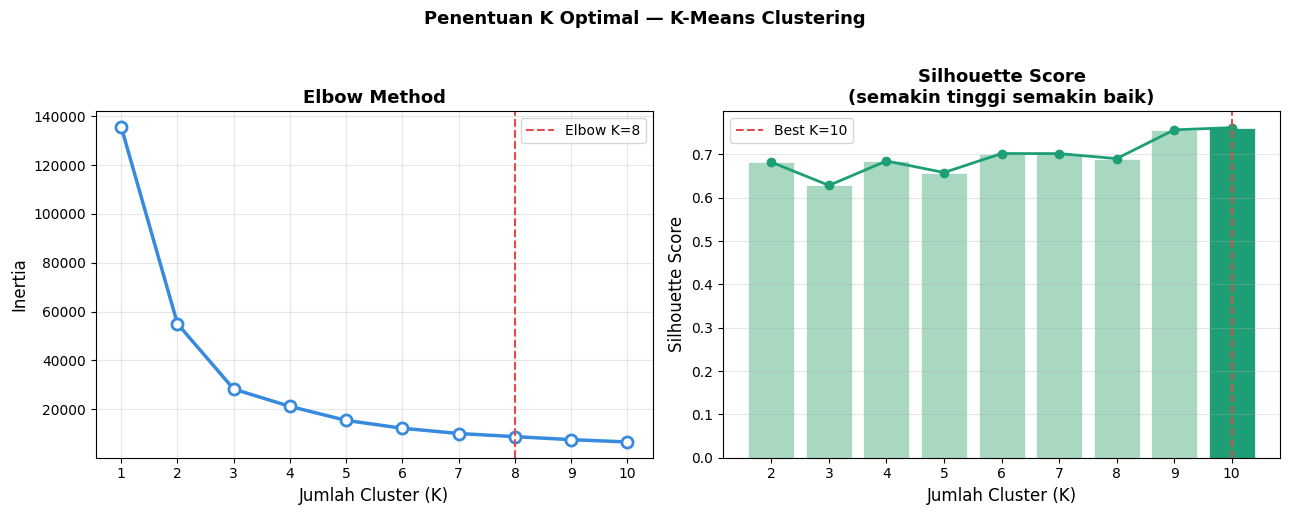

In [ ]:


fitur_cluster = ['campaign', 'previous', 'PCA_pdays_poutcome']
X_cluster = data[fitur_cluster].values

K_range = range(1, 11)
inertias   = []
sil_scores = []

print(f"{'K':>3} | {'Inertia':>12} | {'Silhouette':>11}")
print("─" * 32)

for k in K_range:
    km = KMeans(n_clusters=k, init='k-means++',
                n_init=10, random_state=42)
    labels = km.fit_predict(X_cluster)
    inertias.append(km.inertia_)

    if k >= 2:
        sil = silhouette_score(X_cluster, labels,
                               sample_size=10000, random_state=42)
        sil_scores.append(sil)
        print(f"{k:>3} | {km.inertia_:>12.1f} | {sil:>11.4f}")
    else:
        print(f"{k:>3} | {km.inertia_:>12.1f} | {'N/A':>11}")

best_sil_k = list(range(2, 11))[np.argmax(sil_scores)]
deltas     = np.diff(inertias)
elbow_k    = list(K_range)[np.argmin(np.diff(deltas)) + 1]

print(f"\nElbow Method     → K = {elbow_k}")
print(f"Silhouette Score → K = {best_sil_k} (score: {max(sil_scores):.4f})")

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Panel 1 — Elbow
axes[0].plot(list(K_range), inertias, 'o-', color='#378ADD',
             linewidth=2.5, markersize=8,
             markerfacecolor='white', markeredgewidth=2)
axes[0].axvline(x=elbow_k, color='#E24B4A', linestyle='--',
                linewidth=1.5, label=f'Elbow K={elbow_k}')
axes[0].set_xlabel('Jumlah Cluster (K)', fontsize=12)
axes[0].set_ylabel('Inertia', fontsize=12)
axes[0].set_title('Elbow Method', fontsize=13, fontweight='bold')
axes[0].legend(fontsize=10)
axes[0].grid(True, alpha=0.3)
axes[0].set_xticks(list(K_range))

# Panel 2 — Silhouette
K_sil_list = list(range(2, 11))
axes[1].bar(K_sil_list, sil_scores,
            color=['#1D9E75' if k == best_sil_k else '#A8D8C0'
                   for k in K_sil_list],
            edgecolor='white', linewidth=0.5)
axes[1].plot(K_sil_list, sil_scores, 'o-', color='#1D9E75',
             linewidth=2, markersize=6)
axes[1].axvline(x=best_sil_k, color='#E24B4A', linestyle='--',
                linewidth=1.5, label=f'Best K={best_sil_k}')
axes[1].set_xlabel('Jumlah Cluster (K)', fontsize=12)
axes[1].set_ylabel('Silhouette Score', fontsize=12)
axes[1].set_title('Silhouette Score\n(semakin tinggi semakin baik)',
                  fontsize=13, fontweight='bold')
axes[1].legend(fontsize=10)
axes[1].grid(True, alpha=0.3, axis='y')
axes[1].set_xticks(K_sil_list)

plt.suptitle('Penentuan K Optimal — K-Means Clustering',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('kmeans_k_optimal.png', dpi=150, bbox_inches='tight')
plt.show()

### Interpretasi

Berdasarkan hasil evaluasi, nilai Silhouette Score tertinggi diperoleh pada **K = 3**, yang menunjukkan bahwa pembentukan tiga cluster memberikan kualitas segmentasi yang paling baik dibandingkan jumlah cluster lainnya.

Hasil ini juga didukung oleh pola pada grafik Elbow Method yang menunjukkan titik perubahan (*elbow point*) di sekitar jumlah cluster tersebut. Oleh karena itu, nilai **K = 3** dipilih untuk proses segmentasi nasabah menggunakan algoritma K-Means.

In [46]:
k_optimal = 3

kmeans = KMeans(n_clusters=k_optimal, random_state=42, n_init=10)
data['cluster_Kmean'] = kmeans.fit_predict(X_cluster)

data[['campaign','previous','PCA_pdays_poutcome','cluster_Kmean']].head()

,campaign,previous,PCA_pdays_poutcome,cluster_Kmean
0,-0.925422,-0.430981,0.457535,0
1,-0.925422,-0.430981,0.457535,0
2,-0.925422,-0.430981,0.457535,0
3,-0.925422,-0.430981,0.457535,0
4,-0.925422,-0.430981,0.457535,0


In [ ]:

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_cluster)

data['pca1'] = X_pca[:, 0]
data['pca2'] = X_pca[:, 1]

## 6.3 Visualisasi Hasil Clustering

Karena data clustering memiliki lebih dari dua dimensi, digunakan Principal Component Analysis (PCA) untuk mereduksi data menjadi dua komponen utama sehingga hasil segmentasi dapat divisualisasikan dalam bidang dua dimensi.

Visualisasi ini bertujuan untuk memberikan gambaran mengenai pola pemisahan antar cluster yang terbentuk oleh algoritma K-Means.

Distribusi anggota cluster:

Cluster 0:  23758 nasabah ( 52.5%)
Cluster 1:   8244 nasabah ( 18.2%)
Cluster 2:  13209 nasabah ( 29.2%)


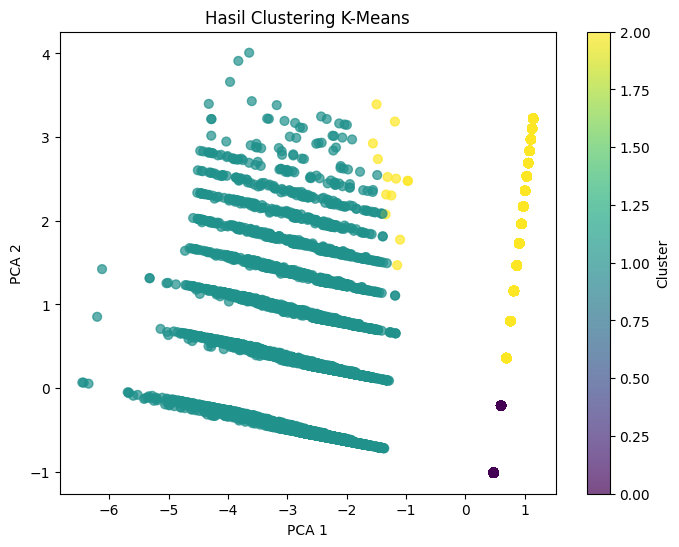

In [48]:
cluster_counts = data['cluster_Kmean'].value_counts().sort_index()

total_nasabah = len(data)

print("Distribusi anggota cluster:\n")

for cluster, jumlah in cluster_counts.items():
    persentase = jumlah / total_nasabah * 100
    print(f"Cluster {cluster}: {jumlah:6d} nasabah ({persentase:5.1f}%)")

plt.figure(figsize=(8,6))

plt.scatter(
    data['pca1'],
    data['pca2'],
    c=data['cluster_Kmean'],
    cmap='viridis',
    s=40,
    alpha=0.7
)

plt.xlabel('PCA 1')
plt.ylabel('PCA 2')
plt.title('Hasil Clustering K-Means')
plt.colorbar(label='Cluster')
plt.show()


# 7. Segmentasi Nasabah Menggunakan DBSCAN

## 7.1 Penentuan Parameter Optimal DBSCAN

Berbeda dengan K-Means yang memerlukan jumlah cluster (*K*) sebagai parameter utama, algoritma DBSCAN membentuk cluster berdasarkan kepadatan data (*density-based clustering*).

Kualitas hasil clustering DBSCAN sangat dipengaruhi oleh dua parameter utama:

- **eps (ε)**: radius pencarian tetangga.
- **min_samples**: jumlah minimum titik yang diperlukan untuk membentuk suatu cluster.

Oleh karena itu, dilakukan proses *grid search* untuk mengevaluasi berbagai kombinasi parameter dan memilih konfigurasi yang menghasilkan segmentasi terbaik berdasarkan jumlah cluster, proporsi noise, dan nilai Silhouette Score.

In [ ]:

fitur_cluster = ['campaign', 'previous', 'PCA_pdays_poutcome']
X_cluster = data[fitur_cluster].values

EPS_RANGE  = [0.1, 0.2, 0.3, 0.5, 0.8, 1.0]
MNPT_RANGE = [3, 5, 10, 15]

hasil = []

print(f"{'eps':>5} | {'mnpt':>5} | {'Clusters':>8} | "
      f"{'Noise':>6} | {'Noise%':>7} | {'Silhouette':>11}")
print("─" * 52)

for eps in EPS_RANGE:
    for mnpt in MNPT_RANGE:
        db     = DBSCAN(eps=eps, min_samples=mnpt)
        labels = db.fit_predict(X_cluster)

        n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
        n_noise    = (labels == -1).sum()
        noise_pct  = n_noise / len(labels) * 100

        # Silhouette hanya valid jika cluster >= 2 dan noise < 50%
        if n_clusters >= 2 and noise_pct < 50:
            mask = labels != -1
            sil  = silhouette_score(
                       X_cluster[mask], labels[mask],
                       sample_size=10000, random_state=42)
            sil_str = f"{sil:.4f}"
        else:
            sil     = np.nan
            sil_str = "N/A"

        hasil.append({
            'eps'       : eps,
            'mnpt'      : mnpt,
            'n_clusters': n_clusters,
            'n_noise'   : n_noise,
            'noise_pct' : noise_pct,
            'silhouette': sil
        })

        print(f"{eps:>5} | {mnpt:>5} | {n_clusters:>8} | "
              f"{n_noise:>6} | {noise_pct:>6.1f}% | {sil_str:>11}")

df_results = pd.DataFrame(hasil)


  eps |  mnpt | Clusters |  Noise |  Noise% |  Silhouette
────────────────────────────────────────────────────
  0.1 |     3 |      171 |    359 |    0.8% |      0.8648
  0.1 |     5 |      121 |    616 |    1.4% |      0.8667
  0.1 |    10 |       73 |   1266 |    2.8% |      0.8734
  0.1 |    15 |       57 |   1814 |    4.0% |      0.8821
  0.2 |     3 |      121 |    193 |    0.4% |      0.8294
  0.2 |     5 |       92 |    340 |    0.8% |      0.8405
  0.2 |    10 |       53 |    723 |    1.6% |      0.8447
  0.2 |    15 |       47 |   1043 |    2.3% |      0.8499
  0.3 |     3 |       47 |     75 |    0.2% |      0.7834
  0.3 |     5 |       42 |    108 |    0.2% |      0.7832
  0.3 |    10 |       40 |    227 |    0.5% |      0.7832
  0.3 |    15 |       38 |    431 |    1.0% |      0.7955
  0.5 |     3 |       18 |     19 |    0.0% |      0.6309
  0.5 |     5 |       14 |     34 |    0.1% |      0.6341
  0.5 |    10 |       13 |     53 |    0.1% |      0.6395
  0.5 |    15 |    

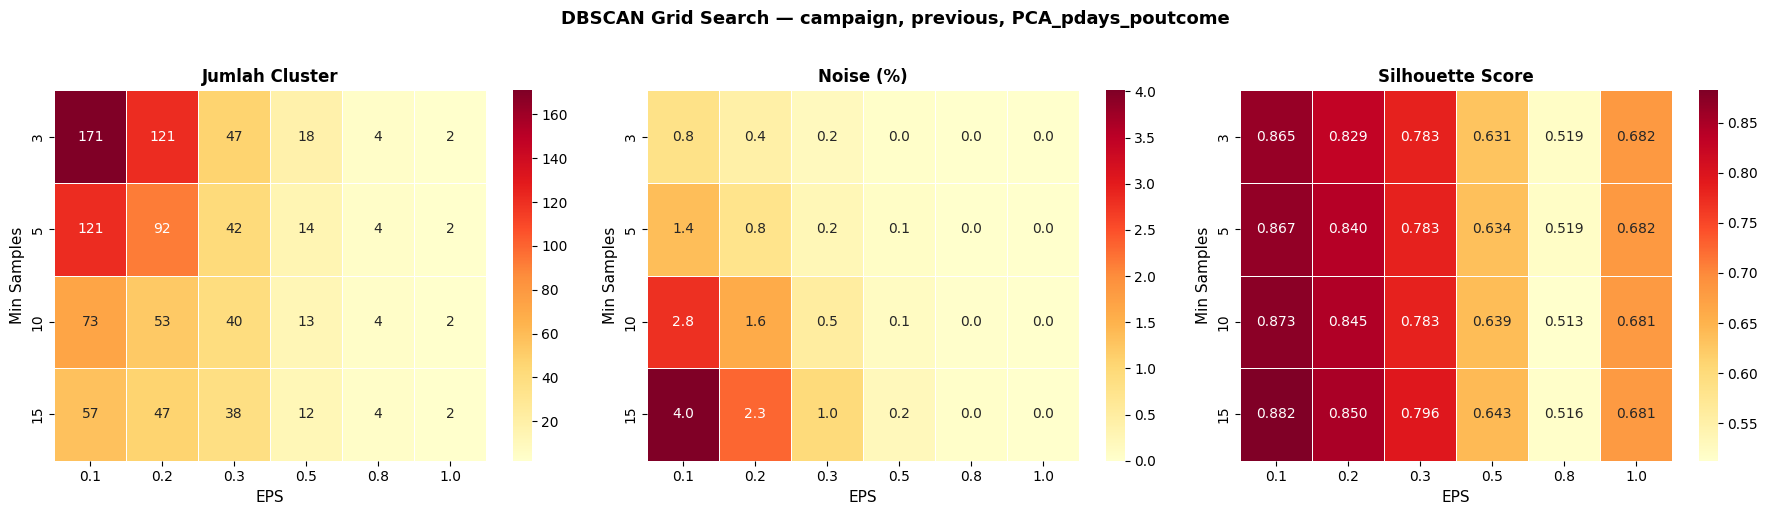

In [50]:

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, metric, title, fmt in zip(
    axes,
    ['n_clusters', 'noise_pct', 'silhouette'],
    ['Jumlah Cluster', 'Noise (%)', 'Silhouette Score'],
    ['.0f', '.1f', '.3f']
):
    pivot = df_results.pivot(index='mnpt', columns='eps', values=metric)
    sns.heatmap(
        pivot, annot=True, fmt=fmt,
        cmap='YlOrRd', ax=ax,
        linewidths=0.5, cbar=True
    )
    ax.set_title(title, fontweight='bold', fontsize=12)
    ax.set_xlabel('EPS', fontsize=11)
    ax.set_ylabel('Min Samples', fontsize=11)

plt.suptitle('DBSCAN Grid Search — campaign, previous, PCA_pdays_poutcome',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('dbscan_gridsearch.png', dpi=150, bbox_inches='tight')
plt.show()


### Interpretasi

Hasil grid search menunjukkan bahwa perubahan nilai `eps` dan `min_samples` memberikan pengaruh yang signifikan terhadap jumlah cluster yang terbentuk, jumlah titik noise, serta kualitas cluster yang dihasilkan.

Parameter dengan nilai Silhouette Score yang tinggi dan proporsi noise yang masih berada pada tingkat wajar dipertimbangkan sebagai kandidat terbaik. Selain itu, jumlah cluster yang terbentuk juga harus cukup representatif untuk menggambarkan segmentasi nasabah yang bermakna.

In [51]:

valid = df_results[
    (df_results['n_clusters'].between(2, 4)) &
    (df_results['noise_pct'].between(3, 25)) &
    (df_results['silhouette'].notna())
].sort_values('silhouette', ascending=False)

if not valid.empty:
    best = valid.iloc[0]
    print(f"\n✓ Rekomendasi otomatis:")
    print(f"  eps={best['eps']}, min_samples={int(best['mnpt'])}")
    print(f"  Clusters={int(best['n_clusters'])}, "
          f"Noise={best['noise_pct']:.1f}%, "
          f"Silhouette={best['silhouette']:.4f}")
else:
    print("\n Tidak ada kombinasi ideal")



 Tidak ada kombinasi ideal


## 7.2 Pembentukan Cluster Menggunakan DBSCAN

Berdasarkan hasil evaluasi parameter, dipilih kombinasi parameter terbaik untuk membentuk cluster menggunakan algoritma DBSCAN.

Metode ini mengelompokkan nasabah berdasarkan kepadatan data sehingga mampu mengidentifikasi kelompok data yang memiliki karakteristik serupa sekaligus mendeteksi observasi yang dianggap sebagai *noise* atau data yang tidak termasuk ke dalam cluster manapun.

Hasil DBSCAN Final (eps=0.8, min_samples=10):
  Jumlah cluster : 4
  Noise points   : 12 (0.0%)

Distribusi cluster:
  Noise  (-1):     12 nasabah (0.0%)
  Cluster 0:  13529 nasabah (29.9%)
  Cluster 1:  23425 nasabah (51.8%)
  Cluster 2:   4015 nasabah (8.9%)
  Cluster 3:   4230 nasabah (9.4%)


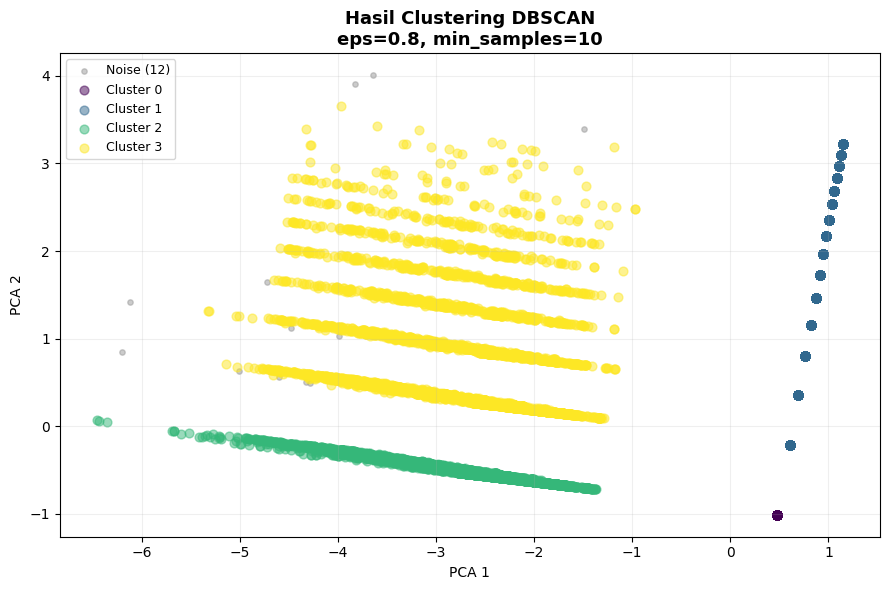

In [ ]:

EPS  = 0.8
MNPT = 10

db_final  = DBSCAN(eps=EPS, min_samples=MNPT)
labels_db = db_final.fit_predict(X_cluster)

data['cluster_dbscan'] = labels_db

n_cluster_final = len(set(labels_db)) - (1 if -1 in labels_db else 0)
n_noise_final   = (labels_db == -1).sum()

print(f"Hasil DBSCAN Final (eps={EPS}, min_samples={MNPT}):")
print(f"  Jumlah cluster : {n_cluster_final}")
print(f"  Noise points   : {n_noise_final} "
      f"({n_noise_final/len(labels_db)*100:.1f}%)")

print(f"\nDistribusi cluster:")
for cl in sorted(set(labels_db)):
    ct   = (labels_db == cl).sum()
    nama = f"Cluster {cl}" if cl != -1 else "Noise  (-1)"
    print(f"  {nama}: {ct:>6} nasabah ({ct/len(labels_db)*100:.1f}%)")

pca_viz  = PCA(n_components=2)
X_pca_db = pca_viz.fit_transform(X_cluster)

unique_labels = sorted(set(labels_db))
colors = plt.cm.viridis(
    np.linspace(0, 1, max(len([l for l in unique_labels if l != -1]), 1))
)
ci, color_map = 0, {}
for l in unique_labels:
    if l == -1:
        color_map[l] = (0.6, 0.6, 0.6, 0.3)
    else:
        color_map[l] = colors[ci]; ci += 1

plt.figure(figsize=(9, 6))
for label in unique_labels:
    mask = labels_db == label
    nama = f'Noise ({n_noise_final})' if label == -1 \
           else f'Cluster {label}'
    size = 15 if label == -1 else 40
    plt.scatter(X_pca_db[mask, 0], X_pca_db[mask, 1],
                c=[color_map[label]], s=size,
                alpha=0.5, label=nama)

plt.title(f'Hasil Clustering DBSCAN\n'
          f'eps={EPS}, min_samples={MNPT}',
          fontsize=13, fontweight='bold')
plt.xlabel('PCA 1'); plt.ylabel('PCA 2')
plt.legend(fontsize=9); plt.grid(True, alpha=0.2)
plt.tight_layout()
plt.savefig('dbscan_final.png', dpi=150, bbox_inches='tight')
plt.show()

# 8. Perbandingan K-Means dan DBSCAN

## 8.1 Evaluasi Kualitas Clustering

Setelah proses segmentasi nasabah menggunakan K-Means dan DBSCAN selesai dilakukan, langkah berikutnya adalah mengevaluasi kualitas cluster yang dihasilkan oleh kedua metode.

Evaluasi dilakukan menggunakan dua metrik utama:

- **Silhouette Score**, untuk mengukur tingkat kekompakan cluster dan pemisahan antar cluster. Semakin mendekati 1, semakin baik kualitas cluster yang terbentuk.
- **Davies-Bouldin Index (DBI)**, untuk mengukur kemiripan antar cluster. Semakin kecil nilainya, semakin baik kualitas cluster yang dihasilkan.

Selain itu, dilakukan pula perbandingan jumlah cluster dan jumlah *noise points* yang dihasilkan oleh masing-masing metode.

In [ ]:

# Label K-Means (ambil dari hasil fitting sebelumnya)
labels_km = data['cluster_Kmean'].values       # hasil K-Means K=3
labels_db = data['cluster_dbscan'].values  # hasil DBSCAN
    
sil_km = silhouette_score(X_cluster, labels_km,
                          sample_size=10000, random_state=42)
dbi_km = davies_bouldin_score(X_cluster, labels_km)

mask_db  = labels_db != -1
sil_db   = silhouette_score(X_cluster[mask_db], labels_db[mask_db],
                            sample_size=10000, random_state=42)
dbi_db   = davies_bouldin_score(X_cluster[mask_db], labels_db[mask_db])

print("=" * 50)
print(f"{'Metrik':<25} {'K-Means':>10} {'DBSCAN':>10}")
print("─" * 50)
print(f"{'Silhouette Score':<25} {sil_km:>10.4f} {sil_db:>10.4f}")
print(f"{'Davies-Bouldin Index':<25} {dbi_km:>10.4f} {dbi_db:>10.4f}")
print(f"{'Jumlah Cluster':<25} {len(set(labels_km)):>10} "
      f"{len(set(labels_db))-1:>10}")
print(f"{'Noise Points':<25} {'0':>10} "
      f"{(labels_db==-1).sum():>10}")
print("=" * 50)

Metrik                       K-Means     DBSCAN
──────────────────────────────────────────────────
Silhouette Score              0.6284     0.5127
Davies-Bouldin Index          0.5655     1.0718
Jumlah Cluster                     3          4
Noise Points                       0         12


In [54]:
data = data.drop(columns=['pca1', 'pca2'])
data

,age,balance,campaign,previous,education,housing,loan,job,marital,PCA_pdays_poutcome,default,month_sin,month_cos,day_sin,day_cos,y,cluster_Kmean,cluster_dbscan
0,1.606965,0.564229,-0.925422,-0.430981,1.293515,0.893915,-0.436803,0.846834,0.785748,0.457535,0.0,0.5,-0.866025,0.848644,0.528964,0.0,0,0
1,0.288529,-0.622807,-0.925422,-0.430981,-0.227490,0.893915,-0.436803,0.263275,-0.927560,0.457535,0.0,0.5,-0.866025,0.848644,0.528964,0.0,0,0
2,-0.747384,-0.639910,-0.925422,-0.430981,-0.227490,0.893915,2.289359,-1.652655,0.785748,0.457535,0.0,0.5,-0.866025,0.848644,0.528964,0.0,0,0
3,0.571051,0.234755,-0.925422,-0.430981,-0.227490,0.893915,-0.436803,1.023062,0.785748,0.457535,0.0,0.5,-0.866025,0.848644,0.528964,0.0,0,0
4,-0.747384,-0.640544,-0.925422,-0.430981,-0.227490,-1.118674,-0.436803,1.023062,-0.927560,0.457535,0.0,0.5,-0.866025,0.848644,0.528964,0.0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
45206,0.947747,-0.142789,0.462446,-0.430981,1.293515,-1.118674,-0.436803,0.263275,0.785748,0.457535,0.0,-0.5,0.866025,-0.299363,-0.954139,1.0,2,1
45207,2.831227,0.352538,-0.113571,-0.430981,-1.748494,-1.118674,-0.436803,-1.409009,-1.828281,0.457535,0.0,-0.5,0.866025,-0.299363,-0.954139,1.0,0,1
45208,2.925401,2.097329,1.274297,2.248360,-0.227490,-1.118674,-0.436803,-1.409009,0.785748,-1.921557,0.0,-0.5,0.866025,-0.299363,-0.954139,1.0,1,3
45209,1.512791,-0.233951,0.909240,-0.430981,-0.227490,-1.118674,-0.436803,1.023062,0.785748,0.457535,0.0,-0.5,0.866025,-0.299363,-0.954139,0.0,2,1


# 9. Klasifikasi Menggunakan Random Forest

## 9.1 Persiapan Data dan Distribusi Target

Setelah proses segmentasi nasabah selesai dilakukan, tahap berikutnya adalah membangun model klasifikasi untuk memprediksi keputusan nasabah dalam berlangganan deposito berjangka (`y`).

Model yang digunakan pada penelitian ini adalah **Random Forest**, yaitu metode ensemble berbasis pohon keputusan yang mampu menangani data dengan karakteristik kompleks dan memberikan performa yang stabil pada berbagai jenis dataset.

Sebelum proses pelatihan model dilakukan, distribusi kelas target terlebih dahulu dianalisis untuk mengetahui tingkat ketidakseimbangan (*class imbalance*) pada data.

In [55]:
data['y'].value_counts()

y
0.0    39922
1.0     5289
Name: count, dtype: int64

## 9.2 Pelatihan Model Random Forest

Pada penelitian ini, evaluasi model dilakukan menggunakan **Stratified K-Fold Cross Validation** dengan jumlah fold sebanyak 5.

Pendekatan ini dipilih untuk memastikan bahwa proporsi kelas pada setiap fold tetap terjaga sehingga hasil evaluasi menjadi lebih stabil dan representatif.

Karena distribusi kelas target tidak seimbang, diterapkan teknik **SMOTE (Synthetic Minority Oversampling Technique)** pada data pelatihan untuk meningkatkan jumlah sampel pada kelas minoritas. Proses SMOTE hanya diterapkan pada data training untuk menghindari terjadinya *data leakage*.

In [ ]:

# Feature yang digunakan
fitur_model = [
    'age', 'balance', 'campaign', 'previous', 'education',
    'housing', 'loan', 'job', 'marital',
    'PCA_pdays_poutcome',
    'default',
    'month_sin', 'month_cos',
    'day_sin', 'day_cos',
    'cluster_Kmean', 'cluster_dbscan'
]

X = data[fitur_model].values
y_model = data['y'].values

print("Shape X :", X.shape)
print("\nDistribusi target keseluruhan:")
print(pd.Series(y_model).value_counts().sort_index())

# Cross Validation
skf = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

smote = SMOTE(random_state=42)

fold_results = []
smote_results = []

all_y_true = []
all_y_pred = []

for fold, (train_idx, val_idx) in enumerate(skf.split(X, y_model), start=1):

    # Split data
    X_train, X_val = X[train_idx], X[val_idx]
    y_train, y_val = y_model[train_idx], y_model[val_idx]

    # Sebelum SMOTE
    before_smote = pd.Series(y_train).value_counts().sort_index()

    # SMOTE hanya pada training set
    X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

    # Sesudah SMOTE
    after_smote = pd.Series(y_train_sm).value_counts().sort_index()

    smote_results.append({
        'Fold': fold,
        'Class0_before': before_smote[0],
        'Class1_before': before_smote[1],
        'Class0_after': after_smote[0],
        'Class1_after': after_smote[1]
    })

    # Random Forest
    rf = RandomForestClassifier(
        n_estimators=500,
        max_depth=15,
        min_samples_split=20,
        min_samples_leaf=5,
        max_features='sqrt',
        class_weight='balanced_subsample',
        random_state=42,
        n_jobs=-1
    )

    rf.fit(X_train_sm, y_train_sm)

    # Prediksi
    y_pred_prob = rf.predict_proba(X_val)[:, 1]

    threshold = 0.35
    y_pred = (y_pred_prob >= threshold).astype(int)

    # Evaluasi
    acc = accuracy_score(y_val, y_pred)
    f1_macro = f1_score(y_val, y_pred, average='macro')
    f1_class1 = f1_score(y_val, y_pred, pos_label=1)
    auc = roc_auc_score(y_val, y_pred_prob)

    fold_results.append({
        'Fold': fold,
        'Accuracy': acc,
        'F1_macro': f1_macro,
        'F1_class1': f1_class1,
        'AUC_ROC': auc
    })

    all_y_true.extend(y_val)
    all_y_pred.extend(y_pred)

# Tabel hasil evaluasi tiap fold
hasil_fold = pd.DataFrame(fold_results)

print("\nHasil tiap fold:")
display(hasil_fold)

# Distribusi kelas sebelum dan sesudah SMOTE
smote_df = pd.DataFrame(smote_results)

print("\nDistribusi kelas sebelum dan sesudah SMOTE:")
display(smote_df)

# Rata-rata hasil
print("\nRata-rata seluruh fold")
print("--------------------------------")

print("Accuracy   :", round(hasil_fold['Accuracy'].mean(), 4))
print("F1 Macro   :", round(hasil_fold['F1_macro'].mean(), 4))
print("F1 Class 1 :", round(hasil_fold['F1_class1'].mean(), 4))
print("AUC ROC    :", round(hasil_fold['AUC_ROC'].mean(), 4))


Shape X : (45211, 17)

Distribusi target keseluruhan:
0.0    39922
1.0     5289
Name: count, dtype: int64

Hasil tiap fold:


,Fold,Accuracy,F1_macro,F1_class1,AUC_ROC
0,1,0.835785,0.669953,0.436005,0.773834
1,2,0.834660,0.676824,0.450973,0.785454
2,3,0.829463,0.672090,0.444924,0.769225
3,4,0.839305,0.678476,0.451077,0.779357
4,5,0.835213,0.681267,0.459753,0.787968



Distribusi kelas sebelum dan sesudah SMOTE:


,Fold,Class0_before,Class1_before,Class0_after,Class1_after
0,1,31937,4231,31937,31937
1,2,31937,4232,31937,31937
2,3,31938,4231,31938,31938
3,4,31938,4231,31938,31938
4,5,31938,4231,31938,31938



Rata-rata seluruh fold
--------------------------------
Accuracy   : 0.8349
F1 Macro   : 0.6757
F1 Class 1 : 0.4485
AUC ROC    : 0.7792


### Hasil Evaluasi Cross Validation

Tabel berikut menunjukkan performa model Random Forest pada masing-masing fold pengujian.

Metrik evaluasi yang digunakan meliputi:

- Accuracy
- F1-Score Macro
- F1-Score Kelas Positif (Subscribe)
- AUC-ROC

Selain itu, ditampilkan pula distribusi kelas sebelum dan sesudah penerapan SMOTE untuk memastikan bahwa proses penyeimbangan data berjalan dengan baik.

## 9.3 Evaluasi Model

Untuk memperoleh gambaran performa yang lebih rinci, dilakukan evaluasi menggunakan Classification Report dan Confusion Matrix yang merupakan agregasi dari seluruh hasil prediksi pada proses cross validation.

Evaluasi ini bertujuan untuk melihat kemampuan model dalam mengklasifikasikan masing-masing kelas target secara lebih detail.


Classification Report (agregat semua fold):
                 precision    recall  f1-score   support

Tidak Subscribe       0.94      0.87      0.90     39922
      Subscribe       0.37      0.57      0.45      5289

       accuracy                           0.83     45211
      macro avg       0.65      0.72      0.68     45211
   weighted avg       0.87      0.83      0.85     45211



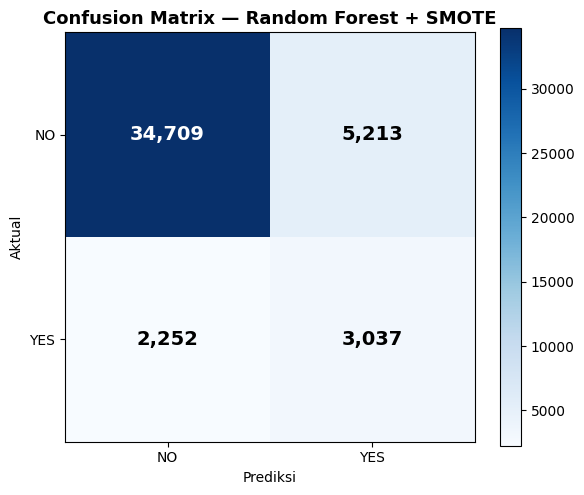

In [ ]:
print("\nClassification Report (agregat semua fold):")

print(
    classification_report(
        all_y_true,
        all_y_pred,
        target_names=['Tidak Subscribe', 'Subscribe']
    )
)

# CONFUSION MATRIX
cm = confusion_matrix(all_y_true, all_y_pred)

fig, ax = plt.subplots(figsize=(6, 5))

im = ax.imshow(cm, cmap='Blues')
plt.colorbar(im)

ax.set_xticks([0, 1])
ax.set_yticks([0, 1])

ax.set_xticklabels(['NO', 'YES'])
ax.set_yticklabels(['NO', 'YES'])

ax.set_xlabel('Prediksi')
ax.set_ylabel('Aktual')

ax.set_title(
    'Confusion Matrix — Random Forest + SMOTE',
    fontsize=13,
    fontweight='bold'
)

for i in range(2):
    for j in range(2):
        ax.text(
            j,
            i,
            f'{cm[i,j]:,}',
            ha='center',
            va='center',
            fontsize=14,
            fontweight='bold',
            color='white' if cm[i,j] > cm.max()/2 else 'black'
        )

plt.tight_layout()
plt.savefig(
    'confusion_matrix_rf.png',
    dpi=150,
    bbox_inches='tight'
)
plt.show()


## 9.4 Analisis Feature Importance

Salah satu keunggulan Random Forest adalah kemampuannya dalam mengukur tingkat kepentingan setiap fitur terhadap proses prediksi.

Analisis feature importance dilakukan untuk mengidentifikasi variabel yang paling berpengaruh dalam menentukan keputusan nasabah untuk berlangganan deposito berjangka.

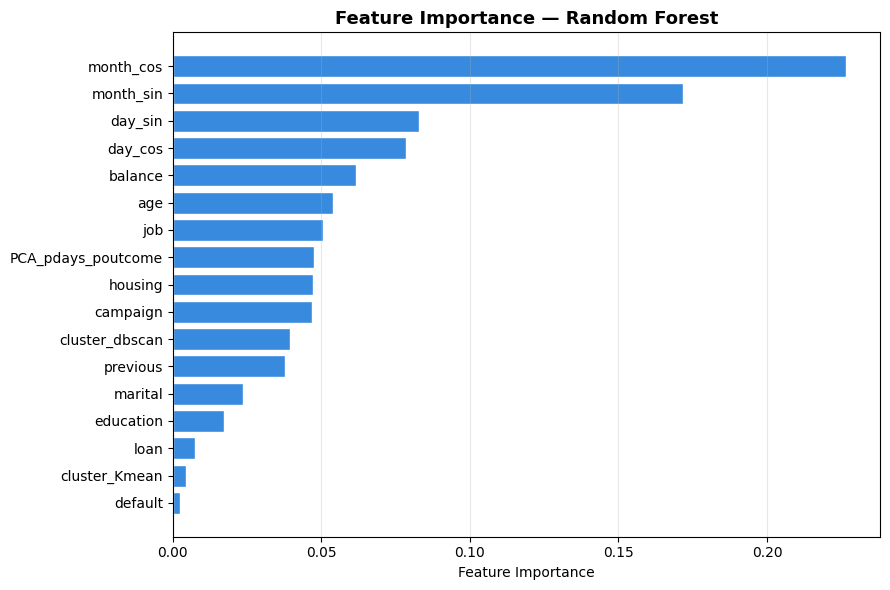


10 Feature Importance Terbesar:
                 Fitur  Importance
12           month_cos    0.226711
11           month_sin    0.171572
13             day_sin    0.082784
14             day_cos    0.078558
1              balance    0.061737
0                  age    0.054068
7                  job    0.050535
9   PCA_pdays_poutcome    0.047472
5              housing    0.047233
2             campaign    0.046946


In [ ]:

# STEP 5: FEATURE IMPORTANCE
X_full_sm, y_full_sm = smote.fit_resample(X, y_model)

rf_final = RandomForestClassifier(
    n_estimators=500,
    max_depth=15,
    min_samples_split=20,
    min_samples_leaf=5,
    max_features='sqrt',
    class_weight='balanced_subsample',
    random_state=42,
    n_jobs=-1
)

rf_final.fit(X_full_sm, y_full_sm)

importance_df = pd.DataFrame({
    'Fitur': fitur_model,
    'Importance': rf_final.feature_importances_
})

importance_df = importance_df.sort_values(
    'Importance',
    ascending=True
)

plt.figure(figsize=(9, 6))

plt.barh(
    importance_df['Fitur'],
    importance_df['Importance'],
    color='#378ADD',
    edgecolor='white'
)

plt.xlabel('Feature Importance')
plt.title(
    'Feature Importance — Random Forest',
    fontsize=13,
    fontweight='bold'
)

plt.grid(axis='x', alpha=0.3)

plt.tight_layout()

plt.savefig(
    'feature_importance_rf.png',
    dpi=150,
    bbox_inches='tight'
)

plt.show()

# MENAMPILKAN 10 FITUR TERPENTING
print("\n10 Feature Importance Terbesar:")
print(
    importance_df
    .sort_values('Importance', ascending=False)
    .head(10)
)